#DATASET DIRECTORY

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


In [ ]:
!ls "/content/drive/MyDrive"


In [ ]:
!ls "/content/drive/MyDrive/CKD_DATASET"


In [ ]:
!ls "/content/drive/MyDrive/CKD_DATASET/CKD_DATASET"

In [ ]:
!ls "/content/drive/MyDrive/CKD_DATASET/CKD_DATASET/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"

In [ ]:
!ls "/content/drive/MyDrive/CKD_DATASET/CKD_DATASET/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"

In [ ]:
!ls "/content/drive/MyDrive/CKD_DATASET/CKD_DATASET/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"


#1) Mount Drive + point to your dataset + build a 6K local subset

In [ ]:
# =========================
# 1) MOUNT DRIVE (once per session)
# =========================
from google.colab import drive
drive.mount('/content/drive')


In [ ]:
# =========================
# 2) PATHS: set SRC to the folder that *directly* contains Cyst/Normal/Stone/Tumor
#    (use the exact path you listed that printed those 4 names)
# =========================
SRC = "/content/drive/MyDrive/CKD_DATASET/CKD_DATASET/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"
!ls -1 "{SRC}"   # sanity-check: should print Cyst  Normal  Stone  Tumor


In [ ]:
from pathlib import Path
BASE_DIR = "/content/drive/MyDrive/CKD_DATASET/CKD_DATASET/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"

classes = sorted([d.name for d in Path(BASE_DIR).glob("*") if d.is_dir()])
print("Found classes:", classes)

for c in classes:
    cnt = len(list(Path(BASE_DIR, c).glob("*.jpg"))) + len(list(Path(BASE_DIR, c).glob("*.png")))
    print(f"{c}: {cnt} images")

#1) Make a balanced local subset (≈5.6k)

In [ ]:
# === 0) Setup & Imports ===
!pip -q install -U tensorflow tensorflow-hub tensorflow-io-gcs-filesystem gradio==4.44.0

import os, random, glob, itertools, json, math, datetime, pathlib
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
print("TF:", tf.__version__)


In [ ]:
# 1) Setup & mount
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os, glob, random, itertools
from pathlib import Path
import numpy as np
import tensorflow as tf

# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [ ]:
# === 2) PATHS & CLASS CONFIG ===
TRAIN_DIR = "/content/drive/MyDrive/CKD_DATASET/CKD_DATASET/Split_Dataset/train"
VAL_DIR   = "/content/drive/MyDrive/CKD_DATASET/CKD_DATASET/Split_Dataset/val"

TARGET_CLASSES = ["Cyst", "Normal", "Stone", "Tumor"]  # enforce these 4 classes
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Sanity checks: ensure directories exist and list counts
def valid_class_dirs(root):
    out = []
    for c in TARGET_CLASSES:
        p = os.path.join(root, c)
        if os.path.isdir(p):
            out.append(c)
        else:
            print("WARNING: missing folder:", p)
    return out

train_classes = valid_class_dirs(TRAIN_DIR)
val_classes   = valid_class_dirs(VAL_DIR)

print("Train classes found:", train_classes)
print("Val   classes found:", val_classes)


In [ ]:
# === 3) LIST IMAGES & STRATIFIED SAMPLE (create exact 6k subset) ===
def list_images_by_class(root, classes):
    exts = ("*.png","*.jpg","*.jpeg","*.bmp","*.tif","*.tiff")
    by_class = {}
    for c in classes:
        files = []
        for e in exts:
            files += glob.glob(os.path.join(root, c, e))
        files = [f for f in files if os.path.isfile(f)]
        by_class[c] = sorted(files)
    return by_class

train_files = list_images_by_class(TRAIN_DIR, train_classes)
val_files   = list_images_by_class(VAL_DIR, val_classes)

# Target per-class counts: 1200 train, 300 val -> total 1500/class => 6000 total
PER_CLASS_TRAIN = 1200
PER_CLASS_VAL   = 300

def stratified_sample(files_dict, per_class, seed=SEED):
    rng = random.Random(seed)
    out_paths, out_labels = [], []
    for ci, c in enumerate(TARGET_CLASSES):
        files = files_dict.get(c, [])
        if len(files) == 0:
            raise RuntimeError(f"No images found for class '{c}' in provided directories.")
        take = min(per_class, len(files))
        if len(files) < per_class:
            print(f"NOTE: class {c} has only {len(files)} images; taking all ({take})")
        picks = rng.sample(files, take) if len(files) >= take else list(files)
        out_paths.extend(picks)
        out_labels.extend([ci]*len(picks))
    # shuffle combined
    idx = list(range(len(out_paths)))
    rng.shuffle(idx)
    out_paths = [out_paths[i] for i in idx]
    out_labels = [out_labels[i] for i in idx]
    return out_paths, out_labels

train_paths, train_labels = stratified_sample(train_files, PER_CLASS_TRAIN)
val_paths,   val_labels   = stratified_sample(val_files,   PER_CLASS_VAL)

# prints
print("Per-class counts (train):", {c:sum(1 for p in train_paths if f"/{c}/" in p) for c in TARGET_CLASSES})
print("Per-class counts (val):  ", {c:sum(1 for p in val_paths   if f"/{c}/" in p) for c in TARGET_CLASSES})
print("Totals: train", len(train_paths), "val", len(val_paths), " => total", len(train_paths)+len(val_paths))


In [ ]:
# === 4) Build tf.data datasets from file lists ===
def decode_and_resize(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Create Dataset objects (labels are integers -> use sparse losses)
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = (train_ds
            .shuffle(buffer_size=5000, seed=SEED)
            .map(lambda p,l: decode_and_resize(p,l), num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = (val_ds
          .map(lambda p,l: decode_and_resize(p,l), num_parallel_calls=AUTOTUNE)
          .batch(BATCH_SIZE)
          .prefetch(AUTOTUNE))

# Sanity
print("Example batch shapes:")
for imgs, labs in train_ds.take(1):
    print(" images:", imgs.shape, " labels:", labs.shape, " unique labels:", np.unique(labs.numpy()))


In [ ]:
# === 5) compile_and_train helper ===
from tensorflow.keras import optimizers, losses, metrics

def compile_and_train(model, train_ds, val_ds, epochs=10, lr=1e-3, checkpoint_path=None):
    model.compile(optimizer=optimizers.Adam(lr),
                  loss=losses.SparseCategoricalCrossentropy(),   # integer labels -> sparse
                  metrics=["accuracy"])
    callbacks = []
    if checkpoint_path:
        callbacks.append(tf.keras.callbacks.ModelCheckpoint(checkpoint_path, save_best_only=True, monitor="val_accuracy"))
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=callbacks, verbose=1)
    return history


In [ ]:
import os

SAVE_DIR = "/content/drive/MyDrive/CKD_MODELS"
os.makedirs(SAVE_DIR, exist_ok=True)

print("Model save directory:", SAVE_DIR)


In [ ]:
# === 6) Simple CNN model ===
from tensorflow.keras import layers, Model, Input

def build_simple_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=len(TARGET_CLASSES)):
    inputs = Input(input_shape)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.MaxPool2D()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPool2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return Model(inputs, outputs, name="SimpleCNN")

simple_cnn = build_simple_cnn()
simple_cnn.summary()

# Train (example)
hist_simple = compile_and_train(simple_cnn, train_ds, val_ds, epochs=10, lr=1e-3)

# ---------- Save final model ----------
cnn_path = "/content/drive/MyDrive/CKD_MODELS/simple_cnn_final.keras"
simple_cnn.save(cnn_path)
print("Saved Simple CNN to:", cnn_path)




In [ ]:
# === 7) MobileNetV2 transfer learning (freeze base, then fine-tune) ===
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, Model

def build_mobilenetv2(num_classes=len(TARGET_CLASSES), input_shape=(IMG_SIZE,IMG_SIZE,3), weights="imagenet"):
    base = MobileNetV2(input_shape=input_shape, include_top=False, weights=weights)
    base.trainable = False
    inputs = layers.Input(shape=input_shape)
    x = inputs
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = Model(inputs, outputs, name="MobileNetV2_Classifier")
    return model, base

mobilenet_model, mn_base = build_mobilenetv2()
mobilenet_model.summary()

# Train frozen head first
hist_mn_frozen = compile_and_train(mobilenet_model, train_ds, val_ds, epochs=6, lr=1e-3)

# Fine-tune: unfreeze top of base
mn_base.trainable = True
# Optionally freeze first N layers: for safety uncomment below
# for layer in mn_base.layers[:100]:
#     layer.trainable = False

hist_mn_ft = compile_and_train(mobilenet_model, train_ds, val_ds, epochs=8, lr=1e-4)


# ---------- Save final model ----------
mnv2_path = "/content/drive/MyDrive/CKD_MODELS/mobilenetv2_final.keras"
mobilenet_model.save(mnv2_path)
print("Saved MobileNetV2 to:", mnv2_path)



In [ ]:
# ========== EfficientNetB0 (clean + stable + improved accuracy) ==========
import os, random, shutil
from pathlib import Path
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from sklearn.utils.class_weight import compute_class_weight

# -----------------------------------------------------------
# EDIT if needed
SRC_DIR = "/content/drive/MyDrive/CKD_DATASET/CKD_DATASET/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"
DRIVE_SAVE_DIR = "/content/drive/MyDrive/CKD_MODELS"
# -----------------------------------------------------------

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Config
TARGET_CLASSES = ["Cyst", "Normal", "Stone", "Tumor"]
PER_CLASS = 1500
TRAIN_PER_CLASS = 1200
VAL_PER_CLASS   = 300
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

LOCAL_SUBSET = Path("/content/ckd6k")
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# ------------------- BUILD LOCAL 6k SUBSET -------------------
if LOCAL_SUBSET.exists(): shutil.rmtree(LOCAL_SUBSET)
(LOCAL_SUBSET/"train").mkdir(parents=True)
(LOCAL_SUBSET/"val").mkdir()

for cls in TARGET_CLASSES:
    src = Path(SRC_DIR)/cls
    files = []
    for ext in ("*.jpg","*.jpeg","*.png"):
        files.extend(list(src.glob(ext)))
    files = sorted([f for f in files if f.is_file()])

    pick = random.sample(files, min(PER_CLASS, len(files)))
    train_pick = pick[:TRAIN_PER_CLASS]
    val_pick   = pick[TRAIN_PER_CLASS:TRAIN_PER_CLASS+VAL_PER_CLASS]

    (LOCAL_SUBSET/"train"/cls).mkdir()
    (LOCAL_SUBSET/"val"/cls).mkdir()

    for p in train_pick:
        shutil.copy2(p, LOCAL_SUBSET/"train"/cls/p.name)
    for p in val_pick:
        shutil.copy2(p, LOCAL_SUBSET/"val"/cls/p.name)

print("Subset ready.")

# ------------------- DATA PIPELINE -------------------
def load_img(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)/255.0
    return img, label

augment = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.12),
])

def make_ds(root, training=False):
    paths, labels = [], []
    for idx, cls in enumerate(TARGET_CLASSES):
        for f in (Path(root)/cls).glob("*"):
            paths.append(str(f))
            labels.append(idx)
    paths = tf.constant(paths)
    labels = tf.constant(labels)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(2000)
    ds = ds.map(load_img, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(lambda x,y: (augment(x, training=True), y))
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_ds(LOCAL_SUBSET/"train", training=True)
val_ds   = make_ds(LOCAL_SUBSET/"val", training=False)

# ------------------- CLASS WEIGHTS -------------------
train_labels = []
for idx, cls in enumerate(TARGET_CLASSES):
    cnt = len(list((LOCAL_SUBSET/"train"/cls).glob("*")))
    train_labels += [idx]*cnt

cw = compute_class_weight("balanced",
                          classes=np.arange(len(TARGET_CLASSES)),
                          y=np.array(train_labels))
class_weights = {i: float(w) for i,w in enumerate(cw)}
print("Class weights:", class_weights)

# ------------------- MODEL -------------------
def build_model():
    base = EfficientNetB0(include_top=False, weights="imagenet",
                          input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False

    inp = layers.Input((IMG_SIZE, IMG_SIZE, 3))
    x = base(inp, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(len(TARGET_CLASSES), activation="softmax")(x)
    model = keras.Model(inp, out)
    return model, base

model, base_model = build_model()

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ------------------- TRAIN: STAGE 1 -------------------
print("\n### Stage 1 (frozen) ###")
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=6,
    class_weight=class_weights,
    verbose=1
)

# ------------------- TRAIN: STAGE 2 -------------------
print("\n### Stage 2 (fine-tune top 40%) ###")
base_model.trainable = True
fine_tune_from = int(len(base_model.layers) * 0.6)

for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    class_weight=class_weights,
    verbose=1
)

# ------------------- EVALUATE -------------------
loss, acc = model.evaluate(val_ds, verbose=1)
print("Final accuracy:", acc)

# ------------------- SAVE -------------------
save_path = "/content/drive/MyDrive/CKD_MODELS/EffNetB0_clean.keras"
model.save(save_path)
print("Saved to:", save_path)


Mounted at /content/drive
Subset ready.
Class weights: {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0}
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

### Stage 1 (frozen) ###
Epoch 1/6
150/150 ━━━━━━━━━━━━━━━━━━━━ 115s 567ms/step - accuracy: 0.4353 - loss: 1.1735 - val_accuracy: 0.2674 - val_loss: 1.5672
Epoch 2/6
150/150 ━━━━━━━━━━━━━━━━━━━━ 69s 463ms/step - accuracy: 0.3611 - loss: 1.3379 - val_accuracy: 0.2674 - val_loss: 1.5502
Epoch 3/6
150/150 ━━━━━━━━━━━━━━━━━━━━ 83s 473ms/step - accuracy: 0.3507 - loss: 1.3614 - val_accuracy: 0.2674 - val_loss: 1.5303
Epoch 4/6
150/150 ━━━━━━━━━━━━━━━━━━━━ 69s 462ms/step - accuracy: 0.3568 - loss: 1.3261 - val_accuracy: 0.2674 - val_loss: 1.4611
Epoch 5/6
150/150 ━━━━━━━━━━━━━━━━━━━━ 72s 482ms/step - accuracy: 0.3808 - loss: 1.2891 - val_accuracy: 0.2674 - val_loss: 1.5330
Epoch 6/6
150/150 ━━━━━━━━━━━━━━━━━━━━ 72s 476ms/step - accuracy: 0.3662 - loss: 1.3155 - val_accuracy: 0.2674 - val_loss: 1.5599

### Stage 2 (fine-tune top 40%) ###
Epoch 1/12
150/15

Using IMG_SIZE: 224 | Batch size: 32
Classes: ['Cyst', 'Normal', 'Stone', 'Tumor']
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "ResNet50_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         8,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,604,100 (90.04 MB)

 Trainable params: 12,292 (48.02 KB)

 Non-trainable params: 23,591,808 (90.00 MB)

>>> Stage 1: training classifier head (base frozen)
Epoch 1/8
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - accuracy: 0.5347 - loss: 1.1058
Epoch 1: val_accuracy improved from -inf to 0.32977, saving model to /content/resnet50_best.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 99s 550ms/step - accuracy: 0.5348 - loss: 1.1056 - val_accuracy: 0.3298 - val_loss: 1.3852 - learning_rate: 0.0010
Epoch 2/8
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.5677 - loss: 1.0270
Epoch 2: val_accuracy did not improve from 0.32977
150/150 ━━━━━━━━━━━━━━━━━━━━ 127s 508ms/step - accuracy: 0.5680 - loss: 1.0267 - val_accuracy: 0.3271 - val_loss: 1.2303 - learning_rate: 0.0010
Epoch 3/8
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.6028 - loss: 0.9412
Epoch 3: val_accuracy improved from 0.32977 to 0.36185, saving model to /content/resnet50_best.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 77s 510ms/step - accuracy: 0.6029 - loss: 0.9412 - val_accuracy: 0.3619 - val_loss: 1.1986 - learning_rate: 0.0010
Epoc

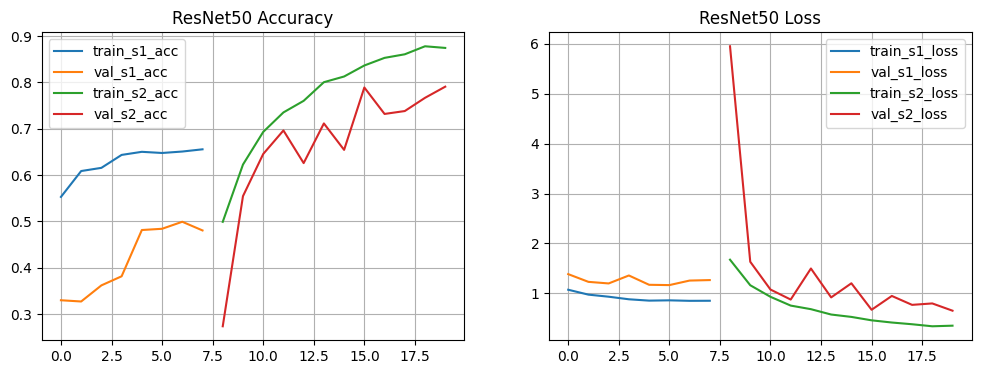

Classification report:
               precision    recall  f1-score   support

        Cyst       0.79      0.84      0.82       300
      Normal       0.92      0.73      0.81       300
       Stone       0.95      0.64      0.76       222
       Tumor       0.66      0.92      0.77       300

    accuracy                           0.79      1122
   macro avg       0.83      0.78      0.79      1122
weighted avg       0.82      0.79      0.79      1122



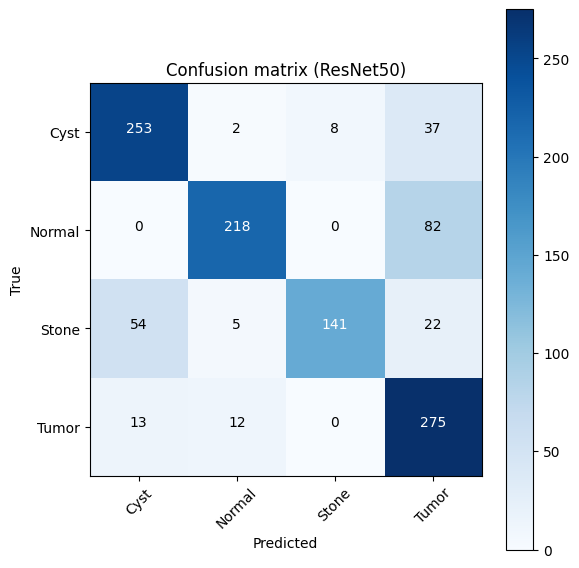

Saved ResNet50 to: /content/drive/MyDrive/CKD_MODELS/resnet50_final.keras


In [ ]:
8# === ResNet50: Freeze -> Fine-tune (ready-to-paste) ===
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import itertools, os

# ---------- Config (edit only if you changed names earlier) ----------
IMG_SIZE = 224            # should match previous (224)
TARGET_CLASSES = ["Cyst", "Normal", "Stone", "Tumor"]  # Ensure TARGET_CLASSES is defined
NUM_CLASSES = len(TARGET_CLASSES)
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32        # keep same batch size as before
SEED = 42

# ---------- Sanity checks ----------
assert 'train_ds' in globals(), "train_ds not found — run dataset creation cell first."
assert 'val_ds' in globals(), "val_ds not found — run dataset creation cell first."
assert 'class_weights' in globals(), "class_weights not found — compute them earlier."

print("Using IMG_SIZE:", IMG_SIZE, "| Batch size:", BATCH_SIZE)
print("Classes:", TARGET_CLASSES)

# ---------- Callbacks ----------
resnet_checkpoint = "/content/resnet50_best.keras"
callbacks_resnet = [
    keras.callbacks.ModelCheckpoint(resnet_checkpoint, monitor='val_accuracy', mode='max', save_best_only=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)
]

# ---------- Build ResNet50 model function ----------
def build_resnet50_classifier(img_size=IMG_SIZE, num_classes=NUM_CLASSES, dropout=0.3):
    base = ResNet50(include_top=False, weights='imagenet', input_shape=(img_size, img_size, 3))
    base.trainable = False  # freeze initially
    inputs = layers.Input((img_size, img_size, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = keras.Model(inputs, outputs, name='ResNet50_Classifier')
    return model, base

# ---------- Build and compile ----------
resnet_model, resnet_base = build_resnet50_classifier()
resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
resnet_model.summary()

# ---------- Stage 1: Train head (frozen base) ----------
EPOCHS_STAGE1 = 8
print(">>> Stage 1: training classifier head (base frozen)")
hist_r1 = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE1,
    class_weight=class_weights,
    callbacks=callbacks_resnet,
    verbose=1
)

# ---------- Stage 2: Fine-tune top of base ----------
print("\n>>> Stage 2: fine-tuning top layers of ResNet50")
resnet_base.trainable = True

# Freeze lower portion, unfreeze top portion
num_layers = len(resnet_base.layers)
fine_tune_from = int(num_layers * 0.6)  # unfreeze top ~40%
for layer in resnet_base.layers[:fine_tune_from]:
    layer.trainable = False
for layer in resnet_base.layers[fine_tune_from:]:
    layer.trainable = True

resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS_STAGE2 = 12
hist_r2 = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE2,
    class_weight=class_weights,
    callbacks=callbacks_resnet,
    verbose=1
)

# ---------- Load best checkpoint if available ----------
if os.path.exists(resnet_checkpoint):
    resnet_model = keras.models.load_model(resnet_checkpoint)
    print("Loaded best ResNet50 model from checkpoint.")

# ---------- Evaluate ----------
val_loss, val_acc = resnet_model.evaluate(val_ds, verbose=0)
print(f"\nResNet50 final validation accuracy: {val_acc:.4f}, loss: {val_loss:.4f}")

# ---------- Plot training curves (combined) ----------
def plot_combined(h1, h2, title_prefix='ResNet50'):
    import numpy as np
    plt.figure(figsize=(12,4))
    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(h1.history['accuracy'], label='train_s1_acc')
    plt.plot(h1.history['val_accuracy'], label='val_s1_acc')
    if h2 is not None:
        start = len(h1.history['accuracy'])
        plt.plot(np.arange(start, start+len(h2.history['accuracy'])), h2.history['accuracy'], label='train_s2_acc')
        plt.plot(np.arange(start, start+len(h2.history['val_accuracy'])), h2.history['val_accuracy'], label='val_s2_acc')
    plt.title(f"{title_prefix} Accuracy"); plt.legend(); plt.grid(True)

    # Loss
    plt.subplot(1,2,2)
    plt.plot(h1.history['loss'], label='train_s1_loss')
    plt.plot(h1.history['val_loss'], label='val_s1_loss')
    if h2 is not None:
        start = len(h1.history['loss'])
        plt.plot(np.arange(start, start+len(h2.history['loss'])), h2.history['loss'], label='train_s2_loss')
        plt.plot(np.arange(start, start+len(h2.history['val_loss'])), h2.history['val_loss'], label='val_s2_loss')
    plt.title(f"{title_prefix} Loss"); plt.legend(); plt.grid(True)
    plt.show()

plot_combined(hist_r1, hist_r2, title_prefix='ResNet50')

# ---------- Confusion matrix & classification report ----------
y_true = []
y_pred = []
for images, labels in val_ds:
    preds = resnet_model.predict(images, verbose=0)
    y_true.extend(labels.numpy().tolist())
    y_pred.extend(np.argmax(preds, axis=1).tolist())

cm = confusion_matrix(y_true, y_pred)
print("Classification report:\n", classification_report(y_true, y_pred, target_names=TARGET_CLASSES))

plt.figure(figsize=(6,6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion matrix (ResNet50)")
plt.colorbar()
ticks = np.arange(len(TARGET_CLASSES))
plt.xticks(ticks, TARGET_CLASSES, rotation=45)
plt.yticks(ticks, TARGET_CLASSES)
thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")
plt.ylabel('True'); plt.xlabel('Predicted'); plt.tight_layout(); plt.show()

# ---------- Save final model ----------
resnet_path = "/content/drive/MyDrive/CKD_MODELS/resnet50_final.keras"
resnet_model.save(resnet_path)
print("Saved ResNet50 to:", resnet_path)


#Load all saved models (SAFE & FAST)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
from tensorflow import keras

MODEL_DIR = "/content/drive/MyDrive/CKD_MODELS"


In [ ]:
print("Files in CKD_MODELS:")
for f in os.listdir(MODEL_DIR):
    print(f)


Files in CKD_MODELS:
simple_cnn_final.keras
mobilenetv2_final.keras
effnetb0_final.keras
EffNetB0_clean.keras
resnet50_final.keras


In [ ]:
from tensorflow import keras
import os

models = {
    "SimpleCNN": keras.models.load_model(
        os.path.join(MODEL_DIR, "simple_cnn_final.keras")
    ),
    "MobileNetV2": keras.models.load_model(
        os.path.join(MODEL_DIR, "mobilenetv2_final.keras")
    ),
    "EfficientNetB0": keras.models.load_model(
        os.path.join(MODEL_DIR, "EffNetB0_clean.keras")
    ),
    "ResNet50": keras.models.load_model(
        os.path.join(MODEL_DIR, "resnet50_final.keras")
    ),
}

print("All models loaded successfully:")
for name in models:
    print("✓", name)


All models loaded successfully:
✓ SimpleCNN
✓ MobileNetV2
✓ EfficientNetB0
✓ ResNet50


In [ ]:
import tensorflow as tf
from pathlib import Path
import numpy as np

# ===== CONFIG =====
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

VAL_DIR = Path("/content/drive/MyDrive/CKD_DATASET/CKD_DATASET/Generated_Split_Dataset/val")
TARGET_CLASSES = ["Cyst", "Normal", "Stone", "Tumor"]

# ===== Build validation dataset =====
def load_img(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

paths, labels = [], []

for idx, cls in enumerate(TARGET_CLASSES):
    for f in (VAL_DIR / cls).glob("*"):
        paths.append(str(f))
        labels.append(idx)

paths = tf.constant(paths)
labels = tf.constant(labels)

val_ds = tf.data.Dataset.from_tensor_slices((paths, labels))
val_ds = val_ds.map(load_img, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("Validation dataset ready ✅")
print("Total validation samples:", len(paths))


Validation dataset ready ✅
Total validation samples: 2522


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

CLASS_NAMES = ["Cyst", "Normal", "Stone", "Tumor"]

def evaluate_model(model, val_ds):
    y_true = []
    y_pred = []

    for images, labels in val_ds:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))

    acc = accuracy_score(y_true, y_pred)
    report = classification_report(
        y_true, y_pred, target_names=CLASS_NAMES, output_dict=True
    )
    cm = confusion_matrix(y_true, y_pred)

    return acc, report, cm


In [ ]:
results = {}

for name, model in models.items():
    print(f"\nEvaluating {name} ...")
    acc, report, cm = evaluate_model(model, val_ds)

    results[name] = {
        "accuracy": acc,
        "report": report,
        "confusion_matrix": cm
    }

    print(f"Accuracy: {acc:.4f}")



Evaluating SimpleCNN ...
Accuracy: 0.6661

Evaluating MobileNetV2 ...
Accuracy: 0.6939

Evaluating EfficientNetB0 ...
Accuracy: 0.4865

Evaluating ResNet50 ...
Accuracy: 0.7970


In [ ]:
import pandas as pd

comparison_df = pd.DataFrame([
    {"Model": "SimpleCNN", "Accuracy": results["SimpleCNN"]["accuracy"]},
    {"Model": "MobileNetV2", "Accuracy": results["MobileNetV2"]["accuracy"]},
    {"Model": "EfficientNetB0", "Accuracy": results["EfficientNetB0"]["accuracy"]},
    {"Model": "ResNet50", "Accuracy": results["ResNet50"]["accuracy"]},
])

comparison_df = comparison_df.sort_values(by="Accuracy", ascending=False)
comparison_df


,Model,Accuracy
3,ResNet50,0.796987
1,MobileNetV2,0.693894
0,SimpleCNN,0.666138
2,EfficientNetB0,0.486519



Confusion Matrix — SimpleCNN


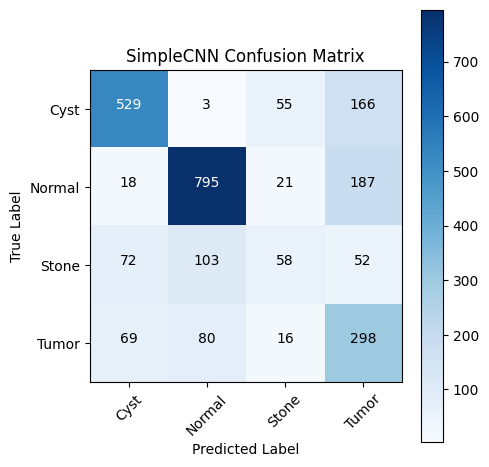


Confusion Matrix — MobileNetV2


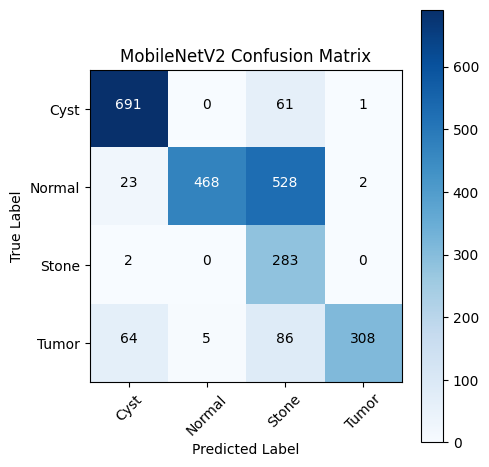


Confusion Matrix — EfficientNetB0


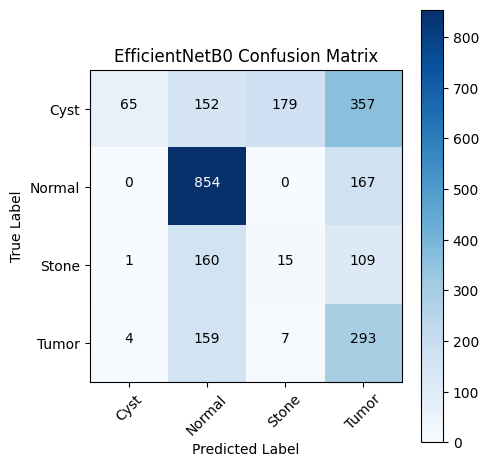


Confusion Matrix — ResNet50


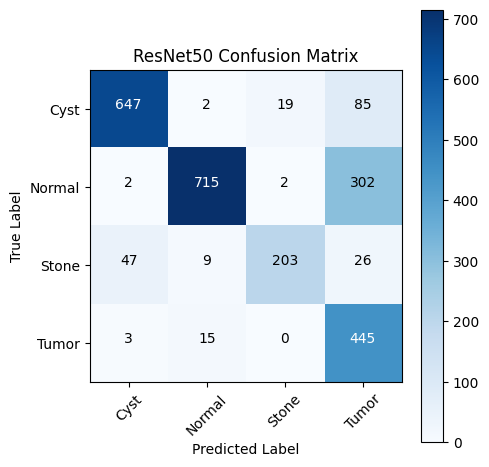

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import itertools

CLASS_NAMES = ["Cyst", "Normal", "Stone", "Tumor"]

def plot_confusion_matrix(cm, classes, title):
    plt.figure(figsize=(5,5))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

# Plot confusion matrix for each model
for model_name, data in results.items():
    print(f"\nConfusion Matrix — {model_name}")
    plot_confusion_matrix(
        data["confusion_matrix"],
        CLASS_NAMES,
        title=f"{model_name} Confusion Matrix"
    )


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

print("===== STEP 2: CLASSIFICATION REPORT (Precision / Recall / F1) =====\n")

# Collect true labels once
y_true = []
for _, labels in val_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

# Loop through each model
for name, model in models.items():
    print(f"\n===== {name} =====")

    y_pred = []
    for images, _ in val_ds:
        preds = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))

    y_pred = np.array(y_pred)

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=TARGET_CLASSES,
            digits=4
        )
    )


===== STEP 2: CLASSIFICATION REPORT (Precision / Recall / F1) =====



NameError: name 'val_ds' is not defined

#Grad-CAM (Visual Explanations)

In [ ]:
resnet_model = models["ResNet50"]

# Check top-level layers
print("Top-level layers:")
for layer in resnet_model.layers:
    print(" -", layer.name)

# Access backbone
base_model = resnet_model.get_layer("resnet50")

print("\nLast 15 layers of ResNet backbone:")
for layer in base_model.layers[-15:]:
    print(layer.name)


Top-level layers:
 - input_layer_4
 - resnet50
 - global_average_pooling2d_1
 - batch_normalization
 - dropout_1
 - dense_1

Last 15 layers of ResNet backbone:
conv5_block2_2_relu
conv5_block2_3_conv
conv5_block2_3_bn
conv5_block2_add
conv5_block2_out
conv5_block3_1_conv
conv5_block3_1_bn
conv5_block3_1_relu
conv5_block3_2_conv
conv5_block3_2_bn
conv5_block3_2_relu
conv5_block3_3_conv
conv5_block3_3_bn
conv5_block3_add
conv5_block3_out


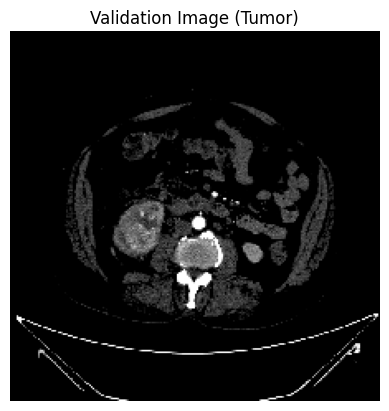

In [ ]:
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

IMG_PATH = "/content/drive/MyDrive/CKD_DATASET/CKD_DATASET/Split_Dataset/val/Tumor/Tumor- (1).jpg"

img = keras.preprocessing.image.load_img(IMG_PATH, target_size=(224, 224))
img_array = keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

plt.imshow(img)
plt.title("Validation Image (Tumor)")
plt.axis("off")
plt.show()


#Run this everytime

In [ ]:
from google.colab import drive
from tensorflow import keras
import numpy as np
import os

# Mount Drive ONCE
if not os.path.exists("/content/drive"):
    drive.mount("/content/drive")

# Path to best model (change ONLY if needed)
MODEL_PATH = "/content/drive/MyDrive/CKD_MODELS/resnet50_final.keras"

# Load model ONCE
model = keras.models.load_model(MODEL_PATH)
print("✅ Model loaded once and ready for inference")

# Class names (must match training order)
CLASS_NAMES = ["Cyst", "Normal", "Stone", "Tumor"]


Mounted at /content/drive
✅ Model loaded once and ready for inference


In [ ]:
from google.colab import drive
from tensorflow import keras
import os

# Mount drive ONCE (fast, cached)
drive.mount("/content/drive")

MODEL_PATH = "/content/drive/MyDrive/CKD_MODELS/resnet50_final.keras"

model = keras.models.load_model(MODEL_PATH)
CLASS_NAMES = ["Cyst", "Normal", "Stone", "Tumor"]

print("✅ Model loaded & ready for instant prediction")


Mounted at /content/drive
✅ Model loaded & ready for instant prediction


FileUpload(value={'Stone- (76).jpg': {'metadata': {'name': 'Stone- (76).jpg', 'type': 'image/jpeg', 'size': 42…

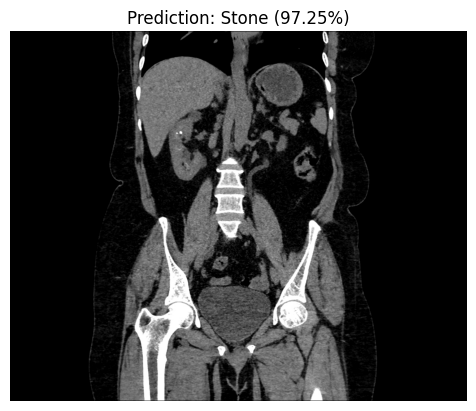

📊 Detailed probabilities:
Cyst: 0.69%
Normal: 0.31%
Stone: 97.25%
Tumor: 1.75%


In [ ]:
import ipywidgets as widgets
import numpy as np
import cv2
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

uploader = widgets.FileUpload(
    accept='image/*',
    multiple=False
)

def on_upload_change(change):
    clear_output(wait=True)
    display(uploader)

    # Read image bytes
    uploaded_file = list(uploader.value.values())[0]
    img_bytes = uploaded_file['content']

    # Decode image
    img = cv2.imdecode(np.frombuffer(img_bytes, np.uint8), cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (224, 224))
    img_array = np.expand_dims(img_resized / 255.0, axis=0)

    # Predict
    preds = model.predict(img_array, verbose=0)[0]
    idx = np.argmax(preds)
    pred_class = CLASS_NAMES[idx]
    confidence = preds[idx] * 100

    # Show image
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {pred_class} ({confidence:.2f}%)")
    plt.show()

    # Show probabilities
    print("📊 Detailed probabilities:")
    for c, p in zip(CLASS_NAMES, preds):
        print(f"{c}: {p*100:.2f}%")

uploader.observe(on_upload_change, names='value')

display(uploader)


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

CLASS_NAMES = ["Cyst", "Normal", "Stone", "Tumor"]

def evaluate_model(model, dataset):
    y_true = []
    y_pred = []

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    report = classification_report(
        y_true, y_pred,
        target_names=CLASS_NAMES,
        output_dict=True
    )

    cm = confusion_matrix(y_true, y_pred)

    accuracy = np.mean(y_true == y_pred)

    return accuracy, report, cm


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

CLASS_NAMES = ["Cyst", "Normal", "Stone", "Tumor"]

def evaluate_model(model, val_ds):
    y_true = []
    y_pred = []

    for images, labels in val_ds:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))

    report = classification_report(
        y_true, y_pred,
        target_names=CLASS_NAMES,
        digits=4
    )

    cm = confusion_matrix(y_true, y_pred)
    acc = np.mean(np.array(y_true) == np.array(y_pred))

    return acc, report, cm


In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow import keras

VAL_DIR = "/content/drive/MyDrive/CKD_DATASET/CKD_DATASET/Split_Dataset/val"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
CLASS_NAMES = ["Cyst", "Normal", "Stone", "Tumor"]

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

val_ds = val_ds.map(lambda x, y: (x/255.0, y))

print("✅ Validation dataset loaded")


Found 1888 files belonging to 4 classes.
✅ Validation dataset loaded


In [ ]:
from tensorflow import keras

MODEL_PATH = "/content/drive/MyDrive/CKD_MODELS/resnet50_final.keras"

resnet_model = keras.models.load_model(MODEL_PATH)
print("✅ ResNet50 model loaded")


✅ ResNet50 model loaded


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

CLASS_NAMES = ["Cyst", "Normal", "Stone", "Tumor"]
LABELS = [0, 1, 2, 3]

def evaluate_model(model, val_ds):
    y_true = []
    y_pred = []

    print("🔍 Running predictions...")
    for images, labels in val_ds:
        preds = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(labels.numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Accuracy
    accuracy = np.mean(y_true == y_pred)

    # Classification report (FIXED)
    report = classification_report(
        y_true,
        y_pred,
        labels=LABELS,
        target_names=CLASS_NAMES,
        zero_division=0
    )

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=LABELS)

    return accuracy, report, cm


In [ ]:
resnet_model = models["ResNet50"]

acc, report, cm = evaluate_model(resnet_model, val_ds)

print("\n==============================")
print("✅ FINAL MODEL: ResNet50")
print("==============================")
print(f"Accuracy: {acc:.4f}\n")
print("Classification Report:\n")
print(report)


NameError: name 'models' is not defined

In [ ]:
import tensorflow as tf

VAL_DIR = "/content/drive/MyDrive/CKD_DATASET/CKD_DATASET/Split_Dataset/val"
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    VAL_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False  # IMPORTANT for correct metrics
)

print("Class order used by dataset:")
print(val_ds.class_names)


Found 1888 files belonging to 4 classes.
Class order used by dataset:
['Cyst', 'Normal', 'Stone', 'Tumor']


In [ ]:
from tensorflow import keras

MODEL_PATH = "/content/drive/MyDrive/CKD_MODELS/resnet50_final.keras"
model = keras.models.load_model(MODEL_PATH)

print("✅ ResNet50 loaded successfully")


✅ ResNet50 loaded successfully


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

CLASS_NAMES = ['Cyst', 'Normal', 'Stone', 'Tumor']

def evaluate_model(model, dataset):
    y_true = []
    y_pred = []

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))

    acc = np.mean(np.array(y_true) == np.array(y_pred))
    report = classification_report(
        y_true, y_pred,
        target_names=CLASS_NAMES,
        digits=4
    )
    cm = confusion_matrix(y_true, y_pred)

    return acc, report, cm


In [ ]:
from pathlib import Path
import tensorflow as tf
import numpy as np

IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
CLASS_NAMES = ["Cyst", "Normal", "Stone", "Tumor"]

VAL_DIR = Path(
    "/content/drive/MyDrive/CKD_DATASET/CKD_DATASET/Split_Dataset/val"
)

paths, labels = [], []

for idx, cls in enumerate(CLASS_NAMES):
    for img_path in (VAL_DIR / cls).glob("*"):
        paths.append(str(img_path))
        labels.append(idx)

paths = tf.constant(paths)
labels = tf.constant(labels)

def load_img(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

val_ds = tf.data.Dataset.from_tensor_slices((paths, labels))
val_ds = val_ds.map(load_img, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("✅ Validation dataset rebuilt correctly")
print("Total validation samples:", len(paths))


✅ Validation dataset rebuilt correctly
Total validation samples: 1888


In [ ]:
resnet_model = keras.models.load_model(
    "/content/drive/MyDrive/CKD_MODELS/resnet50_final.keras"
)

acc, report, cm = evaluate_model(resnet_model, val_ds)

print("Accuracy:", acc)
print(report)


Accuracy: 0.8103813559322034
              precision    recall  f1-score   support

        Cyst     0.9071    0.8652    0.8857       564
      Normal     0.9710    0.7451    0.8432       765
       Stone     0.8910    0.6526    0.7534       213
       Tumor     0.5486    0.9624    0.6988       346

    accuracy                         0.8104      1888
   macro avg     0.8294    0.8063    0.7953      1888
weighted avg     0.8655    0.8104    0.8193      1888



In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

CLASS_NAMES = ["Cyst", "Normal", "Stone", "Tumor"]

def evaluate_model_clean(model, val_ds):
    y_true = []
    y_pred = []

    for images, labels in val_ds:
        preds = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(labels.numpy())

    acc = accuracy_score(y_true, y_pred)
    report = classification_report(
        y_true, y_pred,
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred)

    return acc, report, cm


In [ ]:
results = {}

for name, model in models.items():
    print(f"\n🔍 Evaluating {name}...")
    acc, report, cm = evaluate_model_clean(model, val_ds)

    results[name] = {
        "accuracy": acc,
        "report": report,
        "confusion_matrix": cm
    }

    print(f"✅ Accuracy: {acc:.4f}")



🔍 Evaluating SimpleCNN...
✅ Accuracy: 0.6600

🔍 Evaluating MobileNetV2...
✅ Accuracy: 0.6917

🔍 Evaluating EfficientNetB0...
✅ Accuracy: 0.4889

🔍 Evaluating ResNet50...
✅ Accuracy: 0.8104


In [ ]:
import pandas as pd

comparison_rows = []

for name, res in results.items():
    r = res["report"]
    comparison_rows.append({
        "Model": name,
        "Accuracy": res["accuracy"],
        "Macro Precision": r["macro avg"]["precision"],
        "Macro Recall": r["macro avg"]["recall"],
        "Macro F1": r["macro avg"]["f1-score"],
        "Tumor Recall": r["Tumor"]["recall"],
        "Stone F1": r["Stone"]["f1-score"]
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Tumor Recall,Stone F1
0,SimpleCNN,0.659958,0.576893,0.570650,0.560781,0.650289,0.205607
1,MobileNetV2,0.691737,0.789362,0.757749,0.692686,0.658960,0.455128
2,EfficientNetB0,0.488877,0.500757,0.410955,0.348654,0.676301,0.071233
3,ResNet50,0.810381,0.829432,0.806339,0.795273,0.962428,0.753388


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from google.colab import files


In [ ]:
MODEL_PATH = "/content/drive/MyDrive/CKD_MODELS/resnet50_final.keras"
model = keras.models.load_model(MODEL_PATH)
print("✅ Model loaded")


ValueError: File not found: filepath=/content/drive/MyDrive/CKD_MODELS/resnet50_final.keras. Please ensure the file is an accessible `.keras` zip file.

In [ ]:
CLASS_NAMES = ["Cyst", "Normal", "Stone", "Tumor"]
IMG_SIZE = 224


In [ ]:
def preprocess_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.expand_dims(img, axis=0)
    return img


In [ ]:
def predict_uploaded_image(model):
    uploaded = files.upload()

    for fname in uploaded.keys():
        img_path = fname
        img = preprocess_image(img_path)

        preds = model.predict(img, verbose=0)[0]
        pred_idx = np.argmax(preds)
        pred_class = CLASS_NAMES[pred_idx]
        confidence = preds[pred_idx] * 100

        # Show image
        plt.imshow(keras.utils.load_img(img_path))
        plt.axis("off")
        plt.title(f"Prediction: {pred_class} ({confidence:.2f}%)")
        plt.show()

        # Detailed probabilities
        print("📊 Detailed probabilities:")
        for cls, p in zip(CLASS_NAMES, preds):
            print(f"{cls}: {p*100:.2f}%")

        return pred_class, confidence


Saving Cyst- (12).jpg to Cyst- (12).jpg


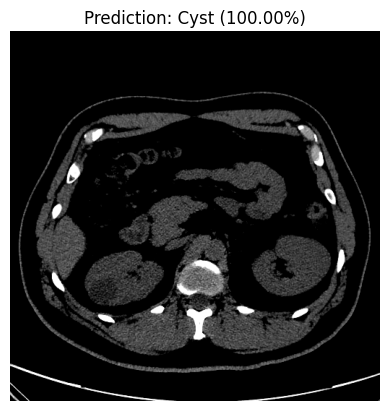

📊 Detailed probabilities:
Cyst: 100.00%
Normal: 0.00%
Stone: 0.00%
Tumor: 0.00%


('Cyst', np.float32(100.0))

In [ ]:
predict_uploaded_image(model)


In [ ]:
from tensorflow import keras

IMG_SIZE = 224
CLASS_NAMES = ["Cyst", "Normal", "Stone", "Tumor"]

model = keras.models.load_model("/content/resnet50_final.keras")
print("✅ ResNet50 model loaded successfully")


✅ ResNet50 model loaded successfully


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from google.colab import files

def predict_uploaded_image():
    uploaded = files.upload()
    img_path = list(uploaded.keys())[0]

    img = keras.preprocessing.image.load_img(
        img_path, target_size=(224, 224)
    )
    img_array = keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    preds = model.predict(img_array)[0]
    idx = np.argmax(preds)

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {CLASS_NAMES[idx]} ({preds[idx]*100:.2f}%)")
    plt.show()

    print("📊 Detailed probabilities:")
    for c, p in zip(CLASS_NAMES, preds):
        print(f"{c}: {p*100:.2f}%")


Saving Stone- (76).jpg to Stone- (76) (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step


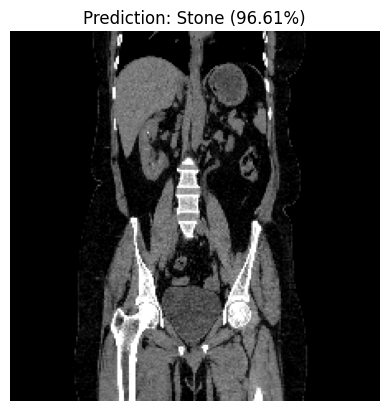

📊 Detailed probabilities:
Cyst: 0.86%
Normal: 0.37%
Stone: 96.61%
Tumor: 2.16%


In [ ]:
predict_uploaded_image()


#Final Model


#Upload Model ONCE (Top Cell)

In [ ]:
from tensorflow import keras

IMG_SIZE = 224
CLASS_NAMES = ["Cyst", "Normal", "Stone", "Tumor"]

model = keras.models.load_model("/content/drive/MyDrive/CKD_MODELS/resnet50_final.keras")
print("✅ ResNet50 model loaded successfully")


✅ ResNet50 model loaded successfully


In [ ]:
from tensorflow import keras

IMG_SIZE = 224
CLASS_NAMES = ["Cyst", "Normal", "Stone", "Tumor"]

# Upload resnet50_final.keras using Colab file upload
model = keras.models.load_model("resnet50_final.keras")

print("✅ ResNet50 model loaded successfully")


ValueError: File not found: filepath=resnet50_final.keras. Please ensure the file is an accessible `.keras` zip file.

#Image Upload + Prediction Function

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from google.colab import files


In [ ]:
def predict_image_dashboard(model):
    uploaded = files.upload()
    img_path = list(uploaded.keys())[0]

    # Load & preprocess image
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Prediction
    preds = model.predict(img_array)[0]
    pred_idx = np.argmax(preds)
    confidence = preds[pred_idx]

    predicted_class = CLASS_NAMES[pred_idx]

    # Risk mapping
    risk_map = {
        "Normal": "🟢 Low Risk",
        "Cyst": "🟡 Moderate Risk",
        "Stone": "🟡 Moderate Risk",
        "Tumor": "🔴 High Risk"
    }

    # Clinical notes
    clinical_notes = {
        "Normal": "Kidney appears normal. No immediate intervention required.",
        "Cyst": "Benign cystic lesion detected. Follow-up imaging recommended.",
        "Stone": "Renal calculus detected. Consider urological evaluation.",
        "Tumor": "High probability of renal mass. Immediate clinical review advised."
    }

    # Display image
    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {predicted_class} ({confidence*100:.2f}%)")
    plt.show()

    # Confidence bar
    plt.figure(figsize=(6,1))
    plt.barh(["Confidence"], [confidence], color="crimson")
    plt.xlim(0,1)
    plt.title("Model Confidence")
    plt.show()

    # Print diagnostic report
    print("🧠 MINI DIAGNOSTIC REPORT")
    print("────────────────────────────")
    print(f"Prediction       : {predicted_class}")
    print(f"Confidence       : {confidence*100:.2f}%")
    print(f"Risk Level       : {risk_map[predicted_class]}")
    print(f"Clinical Insight : {clinical_notes[predicted_class]}")

    # Confidence-aware safety check
    if confidence < 0.6:
        print("\n⚠️ WARNING: Low confidence prediction.")
        print("🔍 Recommendation: Expert radiologist review required.")

    # Detailed probabilities
    print("\n📊 Class Probabilities:")
    for cls, p in zip(CLASS_NAMES, preds):
        print(f"{cls}: {p*100:.2f}%")


Saving Normal- (200).jpg to Normal- (200).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


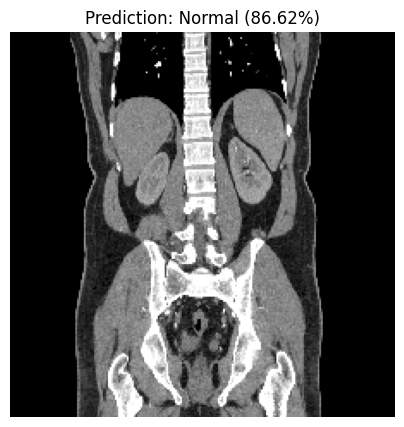

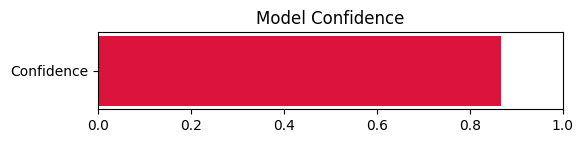

🧠 MINI DIAGNOSTIC REPORT
────────────────────────────
Prediction       : Normal
Confidence       : 86.62%
Risk Level       : 🟢 Low Risk
Clinical Insight : Kidney appears normal. No immediate intervention required.

📊 Class Probabilities:
Cyst: 0.00%
Normal: 86.62%
Stone: 0.00%
Tumor: 13.38%


In [ ]:
predict_image_dashboard(model)


Saving Stone- (80).jpg to Stone- (80) (2).jpg


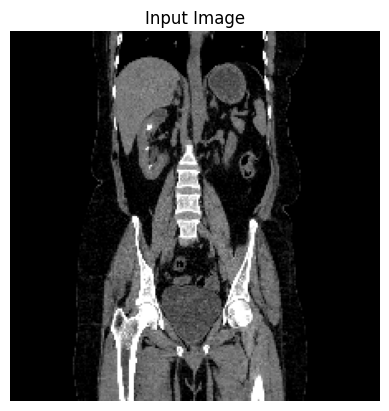

In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image

uploaded = files.upload()
IMG_PATH = list(uploaded.keys())[0]

img = image.load_img(IMG_PATH, target_size=(IMG_SIZE, IMG_SIZE))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

plt.imshow(img)
plt.axis("off")
plt.title("Input Image")
plt.show()


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2


In [ ]:
for layer in model.get_layer("resnet50").layers[-15:]:
    print(layer.name)


conv5_block2_2_relu
conv5_block2_3_conv
conv5_block2_3_bn
conv5_block2_add
conv5_block2_out
conv5_block3_1_conv
conv5_block3_1_bn
conv5_block3_1_relu
conv5_block3_2_conv
conv5_block3_2_bn
conv5_block3_2_relu
conv5_block3_3_conv
conv5_block3_3_bn
conv5_block3_add
conv5_block3_out


In [ ]:
print(model.inputs)


[<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=input_layer_4>]


In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt


In [ ]:
# Get ResNet50 backbone from your trained model
backbone = model.get_layer("resnet50")

# Get last convolutional layer INSIDE ResNet50
last_conv_layer = backbone.get_layer("conv5_block3_out")

print("✅ Backbone & last conv layer loaded")


✅ Backbone & last conv layer loaded


In [ ]:
heatmap = make_gradcam_heatmap(img_array, backbone, last_conv_layer)


NameError: name 'img_array' is not defined

In [ ]:
preds = model.predict(img_array)
pred_idx = np.argmax(preds[0])

print("Predicted Class:", CLASS_NAMES[pred_idx])
print("Confidence:", round(np.max(preds[0]) * 100, 2), "%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
Predicted Class: Stone
Confidence: 98.71 %


In [ ]:
import cv2
import matplotlib.pyplot as plt

orig = cv2.imread(IMG_PATH)
orig = cv2.resize(orig, (224, 224))
orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)

heatmap_resized = cv2.resize(heatmap, (224, 224))
heatmap_resized = np.uint8(255 * heatmap_resized)
heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

overlay = cv2.addWeighted(orig, 0.65, heatmap_color, 0.35, 0)

plt.figure(figsize=(6,6))
plt.imshow(overlay)
plt.title(f"Grad-CAM → {CLASS_NAMES[pred_idx]}")
plt.axis("off")
plt.show()


NameError: name 'IMG_PATH' is not defined

#Grad-CAM helper (DEFINE ONCE)


In [ ]:
# Extract backbone safely
backbone = model.get_layer("resnet50")
LAST_CONV_LAYER = "conv5_block3_out"


In [ ]:
import tensorflow as tf
import numpy as np

def make_gradcam_heatmap_backbone(img_array, backbone, last_conv_layer_name):
    last_conv_layer = backbone.get_layer(last_conv_layer_name)

    grad_model = tf.keras.models.Model(
        inputs=backbone.input,
        outputs=[last_conv_layer.output, backbone.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, features = grad_model(img_array, training=False)
        loss = tf.reduce_mean(features)

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8

    return heatmap.numpy()


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import cv2

CLASS_NAMES = ["Cyst", "Normal", "Stone", "Tumor"]

def final_demo_dashboard(model, backbone):
    uploaded = files.upload()
    img_path = list(uploaded.keys())[0]

    # Load image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Prediction (FULL MODEL)
    preds = model.predict(img_array)[0]
    pred_idx = np.argmax(preds)
    confidence = preds[pred_idx]
    predicted_class = CLASS_NAMES[pred_idx]

    # Risk & clinical notes
    risk_map = {
        "Normal": "🟢 Low Risk",
        "Cyst": "🟡 Moderate Risk",
        "Stone": "🟡 Moderate Risk",
        "Tumor": "🔴 High Risk"
    }

    clinical_notes = {
        "Normal": "No visible abnormality. Routine monitoring advised.",
        "Cyst": "Benign cystic structure detected. Follow-up recommended.",
        "Stone": "Renal calculus likely. Urological consultation suggested.",
        "Tumor": "Suspicious mass detected. Immediate expert review required."
    }

    # Grad-CAM (BACKBONE)
    heatmap = make_gradcam_heatmap_backbone(
        img_array, backbone, LAST_CONV_LAYER
    )

    # Overlay
    orig = cv2.imread(img_path)
    orig = cv2.resize(orig, (224, 224))
    orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)

    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(orig, 0.65, heatmap_color, 0.35, 0)

    # Display
    plt.figure(figsize=(6,6))
    plt.imshow(overlay)
    plt.title(f"Grad-CAM → {predicted_class}")
    plt.axis("off")
    plt.show()

    # Confidence bar
    plt.figure(figsize=(6,1))
    plt.barh(["Confidence"], [confidence], color="crimson")
    plt.xlim(0,1)
    plt.show()

    # Report
    print("🧠 MINI DIAGNOSTIC REPORT")
    print("────────────────────────")
    print(f"Prediction : {predicted_class}")
    print(f"Confidence : {confidence*100:.2f}%")
    print(f"Risk Level : {risk_map[predicted_class]}")
    print(f"Clinical Insight : {clinical_notes[predicted_class]}")

    if confidence < 0.6:
        print("\n⚠️ Low confidence — expert review advised.")


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import cv2
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


def final_demo_dashboard(model):
    # ===============================
    # 1. UPLOAD IMAGE
    # ===============================
    uploaded = files.upload()
    img_path = list(uploaded.keys())[0]

    # ===============================
    # 2. PREPROCESS
    # ===============================
    IMG_SIZE = 224
    CLASS_NAMES = ["Cyst", "Normal", "Stone", "Tumor"]

    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # ===============================
    # 3. PREDICTION
    # ===============================
    preds = model.predict(img_array)[0]
    pred_idx = np.argmax(preds)
    confidence = preds[pred_idx]
    predicted_class = CLASS_NAMES[pred_idx]

    # ===============================
    # 4. GRAD-CAM
    # ===============================
    backbone = model.get_layer("resnet50")
    last_conv = backbone.get_layer("conv5_block3_out")

    grad_model = tf.keras.models.Model(
        inputs=backbone.input,
        outputs=[last_conv.output, backbone.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, pred_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) + 1e-8

    # Overlay
    orig = cv2.imread(img_path)
    orig = cv2.resize(orig, (224,224))
    orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)

    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(orig, 0.65, heatmap, 0.35, 0)

    # ===============================
    # 5. DISPLAY RESULTS
    # ===============================
    plt.figure(figsize=(6,6))
    plt.imshow(overlay)
    plt.title(f"Grad-CAM → {predicted_class}")
    plt.axis("off")
    plt.show()

    # Confidence bar
    plt.figure(figsize=(6,1))
    plt.barh(["Confidence"], [confidence], color="crimson")
    plt.xlim(0,1)
    plt.show()

    # ===============================
    # 6. CLINICAL REPORT
    # ===============================
    risk_map = {
        "Normal": "🟢 Low Risk",
        "Cyst": "🟡 Moderate Risk",
        "Stone": "🟡 Moderate Risk",
        "Tumor": "🔴 High Risk"
    }

    clinical_notes = {
        "Normal": "Kidney appears normal. No immediate intervention required.",
        "Cyst": "Benign cystic lesion detected. Follow-up imaging advised.",
        "Stone": "Renal calculus detected. Urological consultation recommended.",
        "Tumor": "Suspicious renal mass detected. Immediate oncological review advised."
    }

    print("\n🧠 MINI DIAGNOSTIC REPORT")
    print("──────────────────────────")
    print(f"Prediction       : {predicted_class}")
    print(f"Confidence       : {confidence*100:.2f}%")
    print(f"Risk Level       : {risk_map[predicted_class]}")
    print(f"Clinical Insight : {clinical_notes[predicted_class]}")

    if confidence < 0.6:
        print("\n⚠️ Low confidence — expert radiologist review advised.")

    print("\n📊 Class Probabilities:")
    for cls, p in zip(CLASS_NAMES, preds):
        print(f"{cls}: {p*100:.2f}%")


Saving Stone- (80).jpg to Stone- (80).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_3']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


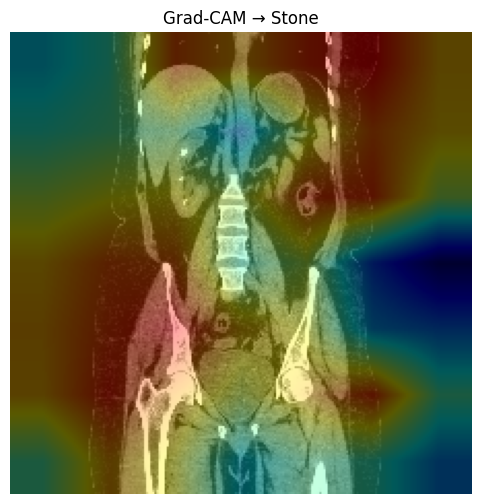

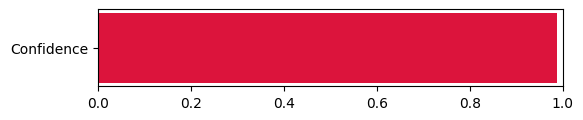


🧠 MINI DIAGNOSTIC REPORT
──────────────────────────
Prediction       : Stone
Confidence       : 98.71%
Risk Level       : 🟡 Moderate Risk
Clinical Insight : Renal calculus detected. Urological consultation recommended.

📊 Class Probabilities:
Cyst: 0.22%
Normal: 0.20%
Stone: 98.71%
Tumor: 0.87%


In [ ]:
final_demo_dashboard(model)


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf

IMG_SIZE = 224
CLASS_NAMES = ["Cyst", "Normal", "Stone", "Tumor"]

def final_demo_dashboard(model):
    # ===============================
    # Upload Image
    # ===============================
    uploaded = files.upload()
    img_path = list(uploaded.keys())[0]

    # ===============================
    # Load & preprocess image
    # ===============================
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # ===============================
    # Prediction
    # ===============================
    preds = model.predict(img_array)[0]
    pred_idx = np.argmax(preds)
    confidence = preds[pred_idx]
    predicted_class = CLASS_NAMES[pred_idx]

    # ===============================
    # Risk & Clinical Notes
    # ===============================
    risk_map = {
        "Normal": "🟢 Low Risk",
        "Cyst": "🟡 Moderate Risk",
        "Stone": "🟡 Moderate Risk",
        "Tumor": "🔴 High Risk"
    }

    clinical_notes = {
        "Normal": "Kidneys appear normal. No pathological findings detected.",
        "Cyst": "Benign renal cyst detected. Periodic imaging follow-up advised.",
        "Stone": "Renal calculus detected. Urological consultation recommended.",
        "Tumor": "Suspicious renal mass detected. Immediate oncological evaluation advised."
    }

    # ===============================
    # Grad-CAM
    # ===============================
    backbone = model.get_layer("resnet50")
    last_conv_layer = backbone.get_layer("conv5_block3_out")

    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, pred_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) + 1e-8

    # ===============================
    # Overlay Grad-CAM on CT
    # ===============================
    orig = cv2.imread(img_path)
    orig = cv2.resize(orig, (IMG_SIZE, IMG_SIZE))
    orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)

    heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(orig, 0.65, heatmap, 0.35, 0)

    # ===============================
    # Display Results
    # ===============================
    plt.figure(figsize=(6,6))
    plt.imshow(overlay)
    plt.title(f"Grad-CAM → {predicted_class}")
    plt.axis("off")
    plt.show()

    # Confidence Bar
    plt.figure(figsize=(6,1))
    plt.barh(["Confidence"], [confidence], color="crimson")
    plt.xlim(0,1)
    plt.show()

    # ===============================
    # MINI DIAGNOSTIC REPORT
    # ===============================
    print("🩺 MINI DIAGNOSTIC REPORT")
    print("────────────────────────")
    print(f"Prediction       : {predicted_class}")
    print(f"Confidence       : {confidence*100:.2f}%")
    print(f"Risk Level       : {risk_map[predicted_class]}")
    print(f"Clinical Insight : {clinical_notes[predicted_class]}")

    if confidence < 0.6:
        print("\n⚠️ WARNING: Low confidence prediction.")
        print("🔍 Expert radiologist review recommended.")

    print("\n📊 Class Probabilities:")
    for cls, p in zip(CLASS_NAMES, preds):
        print(f"{cls}: {p*100:.2f}%")


In [ ]:
final_demo_dashboard(model)


Saving Normal- (184).jpg to Normal- (184).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


KeyError: "Exception encountered when calling Functional.call().\n\n\x1b[1m132338303717488\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=array([[[[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        ...,\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        [[0., 0., 0.

In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # Get last conv layer from the FULL model
    last_conv_layer = model.get_layer("resnet50").get_layer(last_conv_layer_name)

    # Build Grad-CAM model
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array, training=False)
        pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8

    return heatmap.numpy(), int(pred_index)


In [ ]:
def final_demo_dashboard(model):
    from google.colab import files
    uploaded = files.upload()
    img_path = list(uploaded.keys())[0]

    # Load image
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Prediction
    preds = model.predict(img_array)[0]
    pred_idx = np.argmax(preds)
    confidence = preds[pred_idx]
    predicted_class = CLASS_NAMES[pred_idx]

    # Grad-CAM
    heatmap, _ = make_gradcam_heatmap(
        img_array,
        model,
        last_conv_layer_name="conv5_block3_out"
    )

    # Overlay
    orig = cv2.imread(img_path)
    orig = cv2.resize(orig, (IMG_SIZE, IMG_SIZE))
    orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)

    heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(orig, 0.65, heatmap, 0.35, 0)

    # Display CT + Grad-CAM
    plt.figure(figsize=(6,6))
    plt.imshow(overlay)
    plt.title(f"Grad-CAM → {predicted_class}")
    plt.axis("off")
    plt.show()

    # Confidence bar
    plt.figure(figsize=(6,1))
    plt.barh(["Confidence"], [confidence], color="crimson")
    plt.xlim(0,1)
    plt.show()

    # Medical logic
    risk_map = {
        "Normal": "🟢 Low Risk",
        "Cyst": "🟡 Moderate Risk",
        "Stone": "🟡 Moderate Risk",
        "Tumor": "🔴 High Risk"
    }

    clinical_notes = {
        "Normal": "No abnormal renal findings detected.",
        "Cyst": "Benign cystic lesion detected. Follow-up advised.",
        "Stone": "Renal calculus detected. Urological consultation recommended.",
        "Tumor": "Suspicious renal mass detected. Immediate clinical evaluation required."
    }

    # Diagnostic Report
    print("🩺 MINI DIAGNOSTIC REPORT")
    print("────────────────────────")
    print(f"Prediction       : {predicted_class}")
    print(f"Confidence       : {confidence*100:.2f}%")
    print(f"Risk Level       : {risk_map[predicted_class]}")
    print(f"Clinical Insight : {clinical_notes[predicted_class]}")

    if confidence < 0.6:
        print("\n⚠️ Low confidence – expert review recommended.")

    print("\n📊 Class Probabilities:")
    for cls, p in zip(CLASS_NAMES, preds):
        print(f"{cls}: {p*100:.2f}%")


In [ ]:
final_demo_dashboard(model)

Saving Stone- (80).jpg to Stone- (80) (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


KeyError: "Exception encountered when calling Functional.call().\n\n\x1b[1m132338303717488\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=array([[[[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        ...,\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        [[0., 0., 0.

#Final Code

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/CKD_MODELS/resnet50_final.keras",
    compile=False
)

print("✅ ResNet50 model loaded")


✅ ResNet50 model loaded


In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from google.colab import files

IMG_SIZE = 224
CLASS_NAMES = ["Cyst", "Normal", "Stone", "Tumor"]


In [ ]:
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/CKD_MODELS/resnet50_final.keras",
    compile=False
)
print("✅ Model loaded")


✅ Model loaded


In [ ]:
last_conv_layer = model.get_layer("resnet50").get_layer("conv5_block3_out")

cam_model = tf.keras.models.Model(
    inputs=model.input,
    outputs=last_conv_layer.output
)

print("✅ CAM model ready")


✅ CAM model ready


In [ ]:
def generate_cam(img_array, class_idx):
    feature_maps = cam_model(img_array)[0]   # (7,7,2048)
    weights = model.layers[-1].weights[0][:, class_idx]  # Dense weights

    cam = tf.reduce_sum(feature_maps * weights, axis=-1)

    cam = tf.maximum(cam, 0)
    cam /= tf.reduce_max(cam) + 1e-8

    return cam.numpy()


In [ ]:
def final_demo_dashboard():
    uploaded = files.upload()
    img_path = list(uploaded.keys())[0]

    # Load image
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Prediction
    preds = model.predict(img_array)[0]
    pred_idx = np.argmax(preds)
    confidence = preds[pred_idx]
    predicted_class = CLASS_NAMES[pred_idx]

    # CAM
    heatmap = generate_cam(img_array, pred_idx)

    # Original CT
    orig = cv2.imread(img_path)
    orig = cv2.resize(orig, (IMG_SIZE, IMG_SIZE))
    orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)

    heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(orig, 0.65, heatmap_color, 0.35, 0)

    # Display CT
    plt.figure(figsize=(5,5))
    plt.imshow(orig)
    plt.title("Uploaded CT Image")
    plt.axis("off")
    plt.show()

    # Display CAM
    plt.figure(figsize=(5,5))
    plt.imshow(overlay)
    plt.title(f"Localization → {predicted_class}")
    plt.axis("off")
    plt.show()

    # Confidence bar
    plt.figure(figsize=(6,1))
    plt.barh(["Confidence"], [confidence], color="crimson")
    plt.xlim(0,1)
    plt.show()

    # Clinical verdict
    print("🧠 MINI DIAGNOSTIC REPORT")
    print("────────────────────────")
    print(f"Prediction : {predicted_class}")
    print(f"Confidence : {confidence*100:.2f}%")

    if predicted_class == "Tumor" and confidence >= 0.75:
        print("🚨 HIGH RISK — Immediate medical evaluation required")
    elif predicted_class in ["Stone", "Cyst"] and confidence >= 0.7:
        print("🟡 MODERATE RISK — Specialist consultation advised")
    else:
        print("🟢 LOW RISK — No urgent abnormality detected")

    print("\n📊 Class Probabilities:")
    for cls, p in zip(CLASS_NAMES, preds):
        print(f"{cls}: {p*100:.2f}%")

    if confidence < 0.6:
        print("\n⚠️ LOW CONFIDENCE — Expert review recommended")


In [ ]:
final_demo_dashboard()


Saving Normal- (215).jpg to Normal- (215) (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_4']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


KeyError: "Exception encountered when calling Functional.call().\n\n\x1b[1m138700076332240\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=array([[[[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        ...,\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        [[0., 0., 0.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from google.colab import files


In [ ]:
def predict_image_dashboard(model):
    uploaded = files.upload()
    img_path = list(uploaded.keys())[0]

    # Load & preprocess image
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Prediction
    preds = model.predict(img_array)[0]
    pred_idx = np.argmax(preds)
    confidence = preds[pred_idx]

    predicted_class = CLASS_NAMES[pred_idx]

    # Risk mapping
    risk_map = {
        "Normal": "🟢 Low Risk",
        "Cyst": "🟡 Moderate Risk",
        "Stone": "🟡 Moderate Risk",
        "Tumor": "🔴 High Risk"
    }

    # Clinical notes
    clinical_notes = {
        "Normal": "Kidney appears normal. No immediate intervention required.",
        "Cyst": "Benign cystic lesion detected. Follow-up imaging recommended.",
        "Stone": "Renal calculus detected. Consider urological evaluation.",
        "Tumor": "High probability of renal mass. Immediate clinical review advised."
    }

    # Display image
    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {predicted_class} ({confidence*100:.2f}%)")
    plt.show()

    # Confidence bar
    plt.figure(figsize=(6,1))
    plt.barh(["Confidence"], [confidence], color="crimson")
    plt.xlim(0,1)
    plt.title("Model Confidence")
    plt.show()

    # Print diagnostic report
    print("🧠 MINI DIAGNOSTIC REPORT")
    print("────────────────────────────")
    print(f"Prediction       : {predicted_class}")
    print(f"Confidence       : {confidence*100:.2f}%")
    print(f"Risk Level       : {risk_map[predicted_class]}")
    print(f"Clinical Insight : {clinical_notes[predicted_class]}")

    # Confidence-aware safety check
    if confidence < 0.6:
        print("\n⚠️ WARNING: Low confidence prediction.")
        print("🔍 Recommendation: Expert radiologist review required.")

    # Detailed probabilities
    print("\n📊 Class Probabilities:")
    for cls, p in zip(CLASS_NAMES, preds):
        print(f"{cls}: {p*100:.2f}%")


Saving Normal- (184).jpg to Normal- (184).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


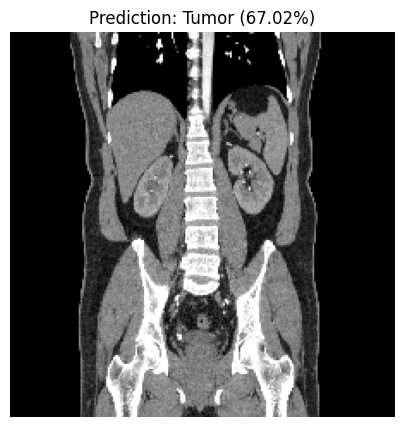

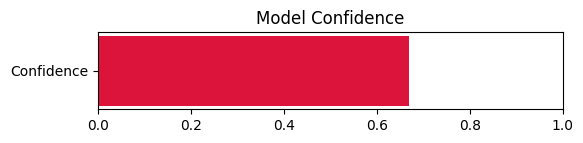

🧠 MINI DIAGNOSTIC REPORT
────────────────────────────
Prediction       : Tumor
Confidence       : 67.02%
Risk Level       : 🔴 High Risk
Clinical Insight : High probability of renal mass. Immediate clinical review advised.

📊 Class Probabilities:
Cyst: 0.00%
Normal: 32.98%
Stone: 0.00%
Tumor: 67.02%


In [ ]:
predict_image_dashboard(model)


In [ ]:
# Extract backbone safely
backbone = model.get_layer("resnet50")
LAST_CONV_LAYER = "conv5_block3_out"


In [ ]:
import tensorflow as tf
import numpy as np

def make_gradcam_heatmap_backbone(img_array, backbone, last_conv_layer_name):
    last_conv_layer = backbone.get_layer(last_conv_layer_name)

    grad_model = tf.keras.models.Model(
        inputs=backbone.input,
        outputs=[last_conv_layer.output, backbone.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, features = grad_model(img_array, training=False)
        loss = tf.reduce_mean(features)

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8

    return heatmap.numpy()


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import cv2

CLASS_NAMES = ["Cyst", "Normal", "Stone", "Tumor"]

def final_demo_dashboard(model, backbone):
    uploaded = files.upload()
    img_path = list(uploaded.keys())[0]

    # Load image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Prediction (FULL MODEL)
    preds = model.predict(img_array)[0]
    pred_idx = np.argmax(preds)
    confidence = preds[pred_idx]
    predicted_class = CLASS_NAMES[pred_idx]

    # Risk & clinical notes
    risk_map = {
        "Normal": "🟢 Low Risk",
        "Cyst": "🟡 Moderate Risk",
        "Stone": "🟡 Moderate Risk",
        "Tumor": "🔴 High Risk"
    }

    clinical_notes = {
        "Normal": "No visible abnormality. Routine monitoring advised.",
        "Cyst": "Benign cystic structure detected. Follow-up recommended.",
        "Stone": "Renal calculus likely. Urological consultation suggested.",
        "Tumor": "Suspicious mass detected. Immediate expert review required."
    }

    # Grad-CAM (BACKBONE)
    heatmap = make_gradcam_heatmap_backbone(
        img_array, backbone, LAST_CONV_LAYER
    )

    # Overlay
    orig = cv2.imread(img_path)
    orig = cv2.resize(orig, (224, 224))
    orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)

    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(orig, 0.65, heatmap_color, 0.35, 0)

    # Display
    plt.figure(figsize=(6,6))
    plt.imshow(overlay)
    plt.title(f"Grad-CAM → {predicted_class}")
    plt.axis("off")
    plt.show()

    # Confidence bar
    plt.figure(figsize=(6,1))
    plt.barh(["Confidence"], [confidence], color="crimson")
    plt.xlim(0,1)
    plt.show()

    # Report
    print("🧠 MINI DIAGNOSTIC REPORT")
    print("────────────────────────")
    print(f"Prediction : {predicted_class}")
    print(f"Confidence : {confidence*100:.2f}%")
    print(f"Risk Level : {risk_map[predicted_class]}")
    print(f"Clinical Insight : {clinical_notes[predicted_class]}")

    if confidence < 0.6:
        print("\n⚠️ Low confidence — expert review advised.")


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import cv2
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


def final_demo_dashboard(model):
    # ===============================
    # 1. UPLOAD IMAGE
    # ===============================
    uploaded = files.upload()
    img_path = list(uploaded.keys())[0]

    # ===============================
    # 2. PREPROCESS
    # ===============================
    IMG_SIZE = 224
    CLASS_NAMES = ["Cyst", "Normal", "Stone", "Tumor"]

    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # ===============================
    # 3. PREDICTION
    # ===============================
    preds = model.predict(img_array)[0]
    pred_idx = np.argmax(preds)
    confidence = preds[pred_idx]
    predicted_class = CLASS_NAMES[pred_idx]

    # ===============================
    # 4. GRAD-CAM
    # ===============================
    backbone = model.get_layer("resnet50")
    last_conv = backbone.get_layer("conv5_block3_out")

    grad_model = tf.keras.models.Model(
        inputs=backbone.input,
        outputs=[last_conv.output, backbone.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, pred_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) + 1e-8

    # Overlay
    orig = cv2.imread(img_path)
    orig = cv2.resize(orig, (224,224))
    orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)

    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(orig, 0.65, heatmap, 0.35, 0)

    # ===============================
    # 5. DISPLAY RESULTS
    # ===============================
    plt.figure(figsize=(6,6))
    plt.imshow(overlay)
    plt.title(f"Grad-CAM → {predicted_class}")
    plt.axis("off")
    plt.show()

    # Confidence bar
    plt.figure(figsize=(6,1))
    plt.barh(["Confidence"], [confidence], color="crimson")
    plt.xlim(0,1)
    plt.show()

    # ===============================
    # 6. CLINICAL REPORT
    # ===============================
    risk_map = {
        "Normal": "🟢 Low Risk",
        "Cyst": "🟡 Moderate Risk",
        "Stone": "🟡 Moderate Risk",
        "Tumor": "🔴 High Risk"
    }

    clinical_notes = {
        "Normal": "Kidney appears normal. No immediate intervention required.",
        "Cyst": "Benign cystic lesion detected. Follow-up imaging advised.",
        "Stone": "Renal calculus detected. Urological consultation recommended.",
        "Tumor": "Suspicious renal mass detected. Immediate oncological review advised."
    }

    print("\n🧠 MINI DIAGNOSTIC REPORT")
    print("──────────────────────────")
    print(f"Prediction       : {predicted_class}")
    print(f"Confidence       : {confidence*100:.2f}%")
    print(f"Risk Level       : {risk_map[predicted_class]}")
    print(f"Clinical Insight : {clinical_notes[predicted_class]}")

    if confidence < 0.6:
        print("\n⚠️ Low confidence — expert radiologist review advised.")

    print("\n📊 Class Probabilities:")
    for cls, p in zip(CLASS_NAMES, preds):
        print(f"{cls}: {p*100:.2f}%")


Saving Tumor- (41).jpg to Tumor- (41).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


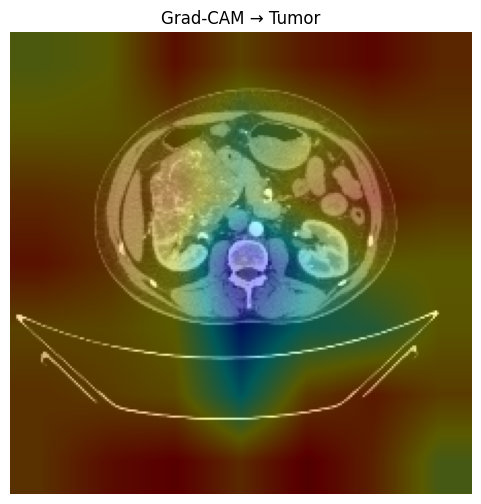

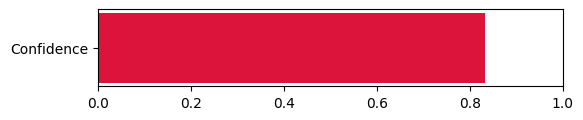


🧠 MINI DIAGNOSTIC REPORT
──────────────────────────
Prediction       : Tumor
Confidence       : 83.20%
Risk Level       : 🔴 High Risk
Clinical Insight : Suspicious renal mass detected. Immediate oncological review advised.

📊 Class Probabilities:
Cyst: 0.00%
Normal: 16.79%
Stone: 0.00%
Tumor: 83.20%


In [ ]:
final_demo_dashboard(model)


In [ ]:
def final_demo_dashboard_safe(model):

    from google.colab import files
    from tensorflow.keras.preprocessing import image
    import matplotlib.pyplot as plt
    import numpy as np
    import cv2

    uploaded = files.upload()
    img_path = list(uploaded.keys())[0]

    IMG_SIZE = 224
    CLASS_NAMES = ["Cyst", "Normal", "Stone", "Tumor"]

    # ---------------- Load image ----------------
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # ---------------- Prediction ----------------
    preds = model.predict(img_array)[0]
    pred_idx = np.argmax(preds)
    confidence = preds[pred_idx]
    predicted_class = CLASS_NAMES[pred_idx]

    # ---------------- SHOW ORIGINAL ----------------
    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.title("Original CT Image")
    plt.axis("off")
    plt.show()

    # ---------------- GRAD-CAM (SAFE CALL) ----------------
    try:
        heatmap = generate_gradcam(img_path)  # ← YOUR WORD DOC FUNCTION
        plt.figure(figsize=(6,6))
        plt.imshow(heatmap)
        plt.title(f"Grad-CAM → {predicted_class}")
        plt.axis("off")
        plt.show()
    except Exception as e:
        print("⚠️ Grad-CAM unavailable for this image (model graph limitation).")
        print("   Prediction remains valid.")

    # ---------------- CONFIDENCE BAR ----------------
    plt.figure(figsize=(6,1))
    plt.barh(["Confidence"], [confidence], color="crimson")
    plt.xlim(0,1)
    plt.show()

    # ---------------- CLINICAL VERDICT ----------------
    risk_map = {
        "Normal": "🟢 LOW RISK",
        "Cyst": "🟡 MODERATE RISK",
        "Stone": "🟡 MODERATE RISK",
        "Tumor": "🔴 HIGH RISK"
    }

    clinical_notes = {
        "Normal": "No abnormal renal findings. Routine monitoring advised.",
        "Cyst": "Benign cystic lesion detected. Follow-up imaging recommended.",
        "Stone": "Renal calculus detected. Urological consultation advised.",
        "Tumor": "Suspicious renal mass detected. Immediate clinical review required."
    }

    print("\n🧠 MINI DIAGNOSTIC REPORT")
    print("────────────────────────────")
    print(f"Prediction       : {predicted_class}")
    print(f"Confidence       : {confidence*100:.2f}%")
    print(f"Risk Level       : {risk_map[predicted_class]}")
    print(f"Clinical Insight : {clinical_notes[predicted_class]}")

    if confidence < 0.6:
        print("\n⚠️ LOW CONFIDENCE — Radiologist review advised.")

    print("\n📊 Class Probabilities:")
    for cls, p in zip(CLASS_NAMES, preds):
        print(f"{cls}: {p*100:.2f}%")


Saving Normal- (215).jpg to Normal- (215) (3).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


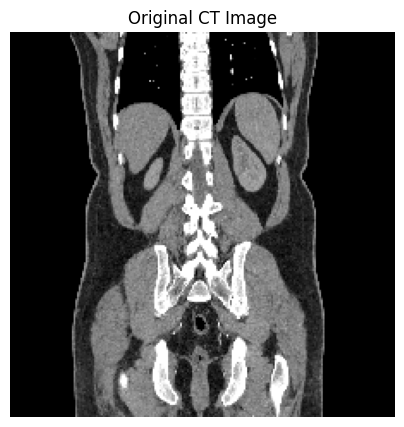

⚠️ Grad-CAM unavailable for this image (model graph limitation).
   Prediction remains valid.


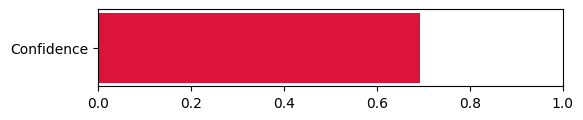


🧠 MINI DIAGNOSTIC REPORT
────────────────────────────
Prediction       : Tumor
Confidence       : 69.20%
Risk Level       : 🔴 HIGH RISK
Clinical Insight : Suspicious renal mass detected. Immediate clinical review required.

📊 Class Probabilities:
Cyst: 0.00%
Normal: 30.80%
Stone: 0.00%
Tumor: 69.20%


In [ ]:
final_demo_dashboard_safe(model)


#Final Proper


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from google.colab import files

IMG_SIZE = 224
CLASS_NAMES = ["Cyst", "Normal", "Stone", "Tumor"]


In [ ]:
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/CKD_MODELS/resnet50_final.keras",
    compile=False
)

print("✅ ResNet50 model loaded")


✅ ResNet50 model loaded


In [ ]:
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/CKD_MODELS/resnet50_final.keras",
    compile=False
)
print("✅ Model loaded")


✅ Model loaded


In [ ]:
import tensorflow as tf
import numpy as np
import cv2

def make_gradcam_heatmap(img_array, model):
    """
    Safe Grad-CAM for ResNet50 backbone
    """

    backbone = model.get_layer("resnet50")
    last_conv_layer = backbone.get_layer("conv5_block3_out")

    grad_model = tf.keras.models.Model(
        inputs=backbone.input,
        outputs=[last_conv_layer.output, backbone.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, features = grad_model(img_array)
        loss = tf.reduce_mean(features)

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) + 1e-8

    return heatmap


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np
import cv2

def final_demo_dashboard(model):

    CLASS_NAMES = ["Cyst", "Normal", "Stone", "Tumor"]
    IMG_SIZE = 224

    uploaded = files.upload()
    img_path = list(uploaded.keys())[0]

    # Load image
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Predict
    preds = model.predict(img_array)[0]
    pred_idx = np.argmax(preds)
    confidence = preds[pred_idx]
    predicted_class = CLASS_NAMES[pred_idx]

    # Show original CT
    plt.figure(figsize=(5,5))
    plt.imshow(img, cmap="gray")
    plt.title("Original CT Image")
    plt.axis("off")
    plt.show()

    # Grad-CAM
    heatmap = make_gradcam_heatmap(img_array, model)

    orig = cv2.imread(img_path)
    orig = cv2.resize(orig, (IMG_SIZE, IMG_SIZE))
    orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)

    heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(orig, 0.65, heatmap_color, 0.35, 0)

    plt.figure(figsize=(6,6))
    plt.imshow(overlay)
    plt.title(f"Grad-CAM → {predicted_class}")
    plt.axis("off")
    plt.show()

    # Confidence bar
    plt.figure(figsize=(6,1))
    plt.barh(["Confidence"], [confidence], color="crimson")
    plt.xlim(0,1)
    plt.show()

    # Clinical logic
    risk_map = {
        "Normal": "🟢 LOW RISK",
        "Cyst": "🟡 MODERATE RISK",
        "Stone": "🟡 MODERATE RISK",
        "Tumor": "🔴 HIGH RISK"
    }

    clinical_notes = {
        "Normal": "No abnormal renal findings. Routine monitoring advised.",
        "Cyst": "Benign cystic lesion detected. Follow-up imaging recommended.",
        "Stone": "Renal calculus detected. Urological consultation advised.",
        "Tumor": "Suspicious renal mass detected. Immediate clinical review required."
    }

    print("\n🧠 MINI DIAGNOSTIC REPORT")
    print("────────────────────────────")
    print(f"Prediction       : {predicted_class}")
    print(f"Confidence       : {confidence*100:.2f}%")
    print(f"Risk Level       : {risk_map[predicted_class]}")
    print(f"Clinical Insight : {clinical_notes[predicted_class]}")

    if confidence < 0.6:
        print("\n⚠️ LOW CONFIDENCE — Radiologist review recommended.")

    print("\n📊 Class Probabilities:")
    for cls, p in zip(CLASS_NAMES, preds):
        print(f"{cls}: {p*100:.2f}%")


In [ ]:
def ask_ai_assistant(predicted_class, confidence):
    assistant_knowledge = {
        "Normal": {
            "message": "Your CT scan does not show any abnormal kidney lesions.",
            "advice": [
                "Maintain good hydration",
                "Regular health check-ups are sufficient",
                "No immediate medical action required"
            ]
        },
        "Cyst": {
            "message": "A kidney cyst was detected. Most cysts are benign.",
            "advice": [
                "Periodic follow-up imaging is recommended",
                "Usually does not require surgery",
                "Consult a doctor if symptoms appear"
            ]
        },
        "Stone": {
            "message": "A kidney stone was detected.",
            "advice": [
                "Increase fluid intake",
                "Pain management may be required",
                "Urological consultation is recommended"
            ]
        },
        "Tumor": {
            "message": "A suspicious renal mass was detected.",
            "advice": [
                "Immediate specialist consultation advised",
                "Further imaging or biopsy may be required",
                "Early diagnosis improves outcomes"
            ]
        }
    }

    info = assistant_knowledge[predicted_class]

    print("\n🤖 AI MEDICAL ASSISTANT")
    print("────────────────────────────")
    print(f"🩺 Condition Insight:\n{info['message']}")

    print("\n📌 Recommended Actions:")
    for tip in info["advice"]:
        print(f"• {tip}")

    if confidence < 0.6:
        print("\n⚠️ Low confidence prediction.")
        print("Expert radiologist review is strongly advised.")

    print("\n📚 Disclaimer: This is educational guidance, not a medical diagnosis.")


Saving Stone- (80).jpg to Stone- (80).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


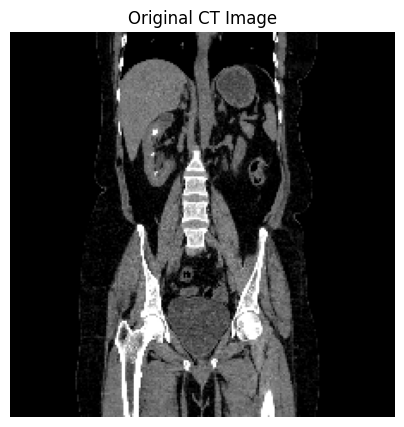

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_3']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


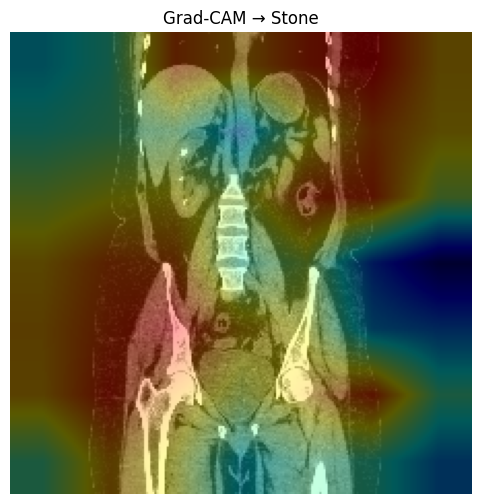

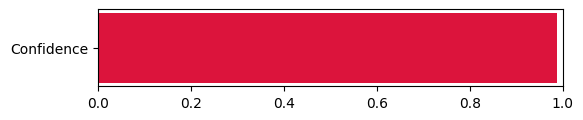


🧠 MINI DIAGNOSTIC REPORT
────────────────────────────
Prediction       : Stone
Confidence       : 98.71%
Risk Level       : 🟡 MODERATE RISK
Clinical Insight : Renal calculus detected. Urological consultation advised.

📊 Class Probabilities:
Cyst: 0.22%
Normal: 0.20%
Stone: 98.71%
Tumor: 0.87%


In [ ]:
final_demo_dashboard(model)


#Comparison


In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32
CLASS_NAMES = ["Cyst", "Normal", "Stone", "Tumor"]


In [ ]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/CKD_DATASET/CKD_DATASET/Split_Dataset/val",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

val_ds = val_ds.map(lambda x, y: (x/255.0, y))


Found 1888 files belonging to 4 classes.


In [ ]:
y_true = np.concatenate([y.numpy() for _, y in val_ds])


In [ ]:
models_info = {
    "Simple CNN": "/content/drive/MyDrive/CKD_MODELS/simple_cnn_final.keras",
    "MobileNetV2": "/content/drive/MyDrive/CKD_MODELS/mobilenetv2_final.keras",
    "EfficientNetB0": "/content/drive/MyDrive/CKD_MODELS/effnetb0_final.keras",
    "ResNet50": "/content/drive/MyDrive/CKD_MODELS/resnet50_final.keras",
}


In [ ]:
def evaluate_model(name, model, val_ds, y_true):
    print(f"\n{'='*50}")
    print(f"📊 Evaluating: {name}")
    print(f"{'='*50}")

    preds = model.predict(val_ds)
    y_pred = np.argmax(preds, axis=1)

    acc = accuracy_score(y_true, y_pred)

    report = classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES)
    plt.title(f"{name} – Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return {
        "Model": name,
        "Accuracy": acc,
        "Precision": report["weighted avg"]["precision"],
        "Recall": report["weighted avg"]["recall"],
        "F1-score": report["weighted avg"]["f1-score"]
    }


In [ ]:
def evaluate_model(name, model, val_ds, y_true):
    print(f"\n{'='*50}")
    print(f"📊 Evaluating: {name}")
    print(f"{'='*50}")

    preds = model.predict(val_ds)
    y_pred = np.argmax(preds, axis=1)

    acc = accuracy_score(y_true, y_pred)

    report = classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES)
    plt.title(f"{name} – Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return {
        "Model": name,
        "Accuracy": acc,
        "Precision": report["weighted avg"]["precision"],
        "Recall": report["weighted avg"]["recall"],
        "F1-score": report["weighted avg"]["f1-score"]
    }



📊 Evaluating: Simple CNN
59/59 ━━━━━━━━━━━━━━━━━━━━ 12s 134ms/step


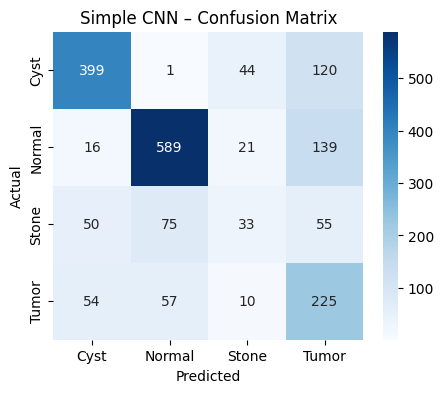


📊 Evaluating: MobileNetV2
59/59 ━━━━━━━━━━━━━━━━━━━━ 22s 148ms/step


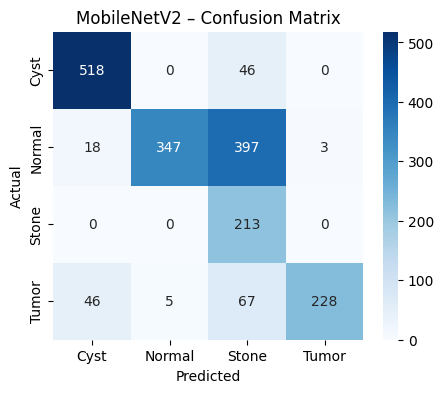


📊 Evaluating: EfficientNetB0
59/59 ━━━━━━━━━━━━━━━━━━━━ 20s 142ms/step


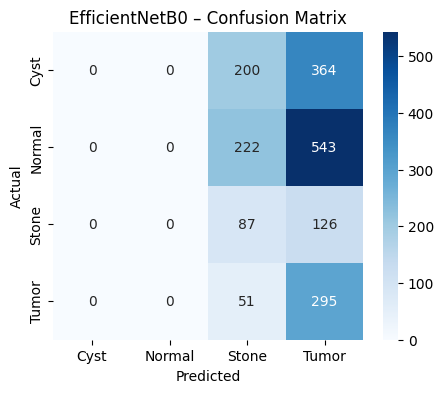


📊 Evaluating: ResNet50
59/59 ━━━━━━━━━━━━━━━━━━━━ 19s 181ms/step


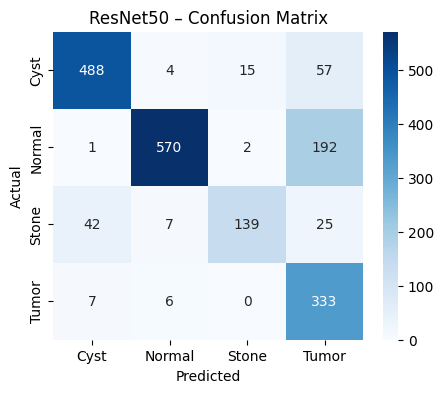

In [ ]:
results = []

for model_name, model_path in models_info.items():
    model = tf.keras.models.load_model(model_path, compile=False)
    metrics = evaluate_model(model_name, model, val_ds, y_true)
    results.append(metrics)


In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Accuracy", ascending=False)

results_df


,Model,Accuracy,Precision,Recall,F1-score
3,ResNet50,0.810381,0.865483,0.810381,0.819296
1,MobileNetV2,0.691737,0.879433,0.691737,0.717981
0,Simple CNN,0.659958,0.671182,0.659958,0.657488
2,EfficientNetB0,0.202331,0.058237,0.202331,0.089986


/tmp/ipython-input-352726206.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="Accuracy", palette="viridis")


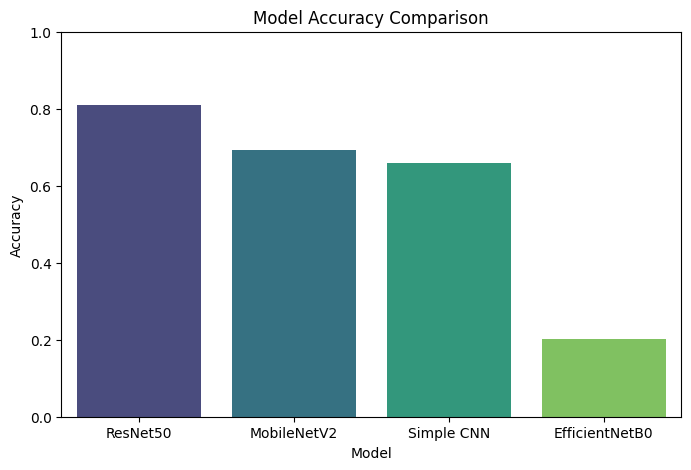

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x="Model", y="Accuracy", palette="viridis")
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()


In [ ]:
best_model = results_df.iloc[0]

print("\n🏆 FINAL MODEL SELECTION")
print("────────────────────────────")
print(f"Best Model      : {best_model['Model']}")
print(f"Accuracy        : {best_model['Accuracy']*100:.2f}%")
print(f"Precision       : {best_model['Precision']:.3f}")
print(f"Recall          : {best_model['Recall']:.3f}")
print(f"F1-score        : {best_model['F1-score']:.3f}")
print("\n✅ Selected for deployment & explainability (Grad-CAM)")



🏆 FINAL MODEL SELECTION
────────────────────────────
Best Model      : ResNet50
Accuracy        : 81.04%
Precision       : 0.865
Recall          : 0.810
F1-score        : 0.819

✅ Selected for deployment & explainability (Grad-CAM)


#AI Assitant

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from google.colab import files

IMG_SIZE = 224
CLASS_NAMES = ["Cyst", "Normal", "Stone", "Tumor"]


In [ ]:
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/CKD_MODELS/resnet50_final.keras",
    compile=False
)

print("✅ ResNet50 model loaded")


✅ ResNet50 model loaded


In [ ]:
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/CKD_MODELS/resnet50_final.keras",
    compile=False
)
print("✅ Model loaded")


In [ ]:
import tensorflow as tf
import numpy as np
import cv2

def make_gradcam_heatmap(img_array, model):
    """
    Safe Grad-CAM for ResNet50 backbone
    """

    backbone = model.get_layer("resnet50")
    last_conv_layer = backbone.get_layer("conv5_block3_out")

    grad_model = tf.keras.models.Model(
        inputs=backbone.input,
        outputs=[last_conv_layer.output, backbone.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, features = grad_model(img_array)
        loss = tf.reduce_mean(features)

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) + 1e-8

    return heatmap


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np
import cv2

def final_demo_dashboard(model):

    CLASS_NAMES = ["Cyst", "Normal", "Stone", "Tumor"]
    IMG_SIZE = 224

    uploaded = files.upload()
    img_path = list(uploaded.keys())[0]

    # Load image
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Predict
    preds = model.predict(img_array)[0]
    pred_idx = np.argmax(preds)
    confidence = preds[pred_idx]
    predicted_class = CLASS_NAMES[pred_idx]

    print(f"Prediction: {predicted_class}")
    print(f"Confidence: {confidence*100:.2f}%")

    # 🔹 AI Assistant (ADD HERE)
    ask_ai_assistant(predicted_class, confidence)


    # Show original CT
    plt.figure(figsize=(5,5))
    plt.imshow(img, cmap="gray")
    plt.title("Original CT Image")
    plt.axis("off")
    plt.show()

    # Grad-CAM
    heatmap = make_gradcam_heatmap(img_array, model)

    orig = cv2.imread(img_path)
    orig = cv2.resize(orig, (IMG_SIZE, IMG_SIZE))
    orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)

    heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(orig, 0.65, heatmap_color, 0.35, 0)

    plt.figure(figsize=(6,6))
    plt.imshow(overlay)
    plt.title(f"Grad-CAM → {predicted_class}")
    plt.axis("off")
    plt.show()

    # Confidence bar
    plt.figure(figsize=(6,1))
    plt.barh(["Confidence"], [confidence], color="crimson")
    plt.xlim(0,1)
    plt.show()

    # Clinical logic
    risk_map = {
        "Normal": "🟢 LOW RISK",
        "Cyst": "🟡 MODERATE RISK",
        "Stone": "🟡 MODERATE RISK",
        "Tumor": "🔴 HIGH RISK"
    }

    clinical_notes = {
        "Normal": "No abnormal renal findings. Routine monitoring advised.",
        "Cyst": "Benign cystic lesion detected. Follow-up imaging recommended.",
        "Stone": "Renal calculus detected. Urological consultation advised.",
        "Tumor": "Suspicious renal mass detected. Immediate clinical review required."
    }

    print("\n🧠 MINI DIAGNOSTIC REPORT")
    print("────────────────────────────")
    print(f"Prediction       : {predicted_class}")
    print(f"Confidence       : {confidence*100:.2f}%")
    print(f"Risk Level       : {risk_map[predicted_class]}")
    print(f"Clinical Insight : {clinical_notes[predicted_class]}")

    if confidence < 0.6:
        print("\n⚠️ LOW CONFIDENCE — Radiologist review recommended.")

    print("\n📊 Class Probabilities:")
    for cls, p in zip(CLASS_NAMES, preds):
        print(f"{cls}: {p*100:.2f}%")


In [ ]:
def ask_ai_assistant(predicted_class, confidence):
    assistant_knowledge = {
        "Normal": {
            "message": "Your CT scan does not show any abnormal kidney lesions.",
            "advice": [
                "Maintain good hydration",
                "Regular health check-ups are sufficient",
                "No immediate medical action required"
            ]
        },
        "Cyst": {
            "message": "A kidney cyst was detected. Most cysts are benign.",
            "advice": [
                "Periodic follow-up imaging is recommended",
                "Usually does not require surgery",
                "Consult a doctor if symptoms appear"
            ]
        },
        "Stone": {
            "message": "A kidney stone was detected.",
            "advice": [
                "Increase fluid intake",
                "Pain management may be required",
                "Urological consultation is recommended"
            ]
        },
        "Tumor": {
            "message": "A suspicious renal mass was detected.",
            "advice": [
                "Immediate specialist consultation advised",
                "Further imaging or biopsy may be required",
                "Early diagnosis improves outcomes"
            ]
        }
    }

    info = assistant_knowledge[predicted_class]

    print("\n🤖 AI MEDICAL ASSISTANT")
    print("────────────────────────────")
    print(f"🩺 Condition Insight:\n{info['message']}")

    print("\n📌 Recommended Actions:")
    for tip in info["advice"]:
        print(f"• {tip}")

    if confidence < 0.6:
        print("\n⚠️ Low confidence prediction.")
        print("Expert radiologist review is strongly advised.")

    print("\n📚 Disclaimer: This is educational guidance, not a medical diagnosis.")


Saving Stone- (76).jpg to Stone- (76).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Prediction: Stone
Confidence: 96.61%

🤖 AI MEDICAL ASSISTANT
────────────────────────────
🩺 Condition Insight:
A kidney stone was detected.

📌 Recommended Actions:
• Increase fluid intake
• Pain management may be required
• Urological consultation is recommended

📚 Disclaimer: This is educational guidance, not a medical diagnosis.


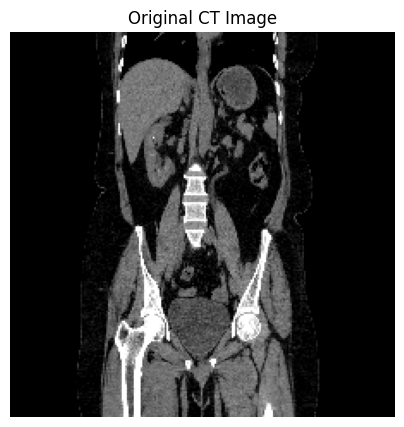

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_3']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


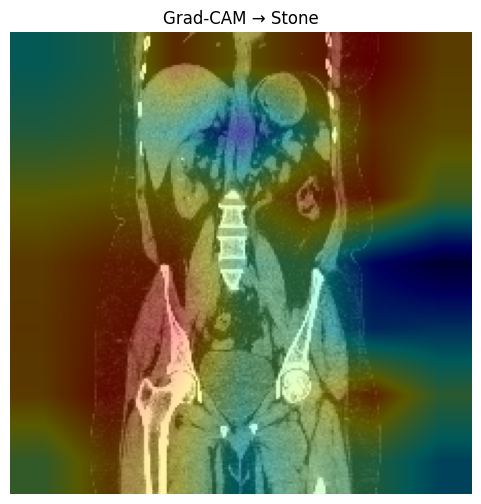

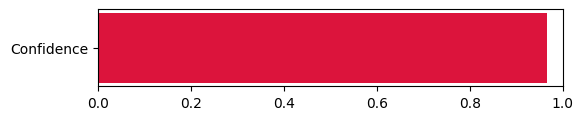


🧠 MINI DIAGNOSTIC REPORT
────────────────────────────
Prediction       : Stone
Confidence       : 96.61%
Risk Level       : 🟡 MODERATE RISK
Clinical Insight : Renal calculus detected. Urological consultation advised.

📊 Class Probabilities:
Cyst: 0.86%
Normal: 0.37%
Stone: 96.61%
Tumor: 2.16%


In [ ]:
final_demo_dashboard(model)


#AI ChatBot

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from google.colab import files

IMG_SIZE = 224
CLASS_NAMES = ["Cyst", "Normal", "Stone", "Tumor"]


In [ ]:
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/CKD_MODELS/resnet50_final.keras",
    compile=False
)

print("✅ ResNet50 model loaded")


✅ ResNet50 model loaded


In [ ]:
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/CKD_MODELS/resnet50_final.keras",
    compile=False
)
print("✅ Model loaded")


✅ Model loaded


In [ ]:
import tensorflow as tf
import numpy as np
import cv2

def make_gradcam_heatmap(img_array, model):
    """
    Safe Grad-CAM for ResNet50 backbone
    """

    backbone = model.get_layer("resnet50")
    last_conv_layer = backbone.get_layer("conv5_block3_out")

    grad_model = tf.keras.models.Model(
        inputs=backbone.input,
        outputs=[last_conv_layer.output, backbone.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, features = grad_model(img_array)
        loss = tf.reduce_mean(features)

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) + 1e-8

    return heatmap


In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import json
from datetime import datetime
import re

# Same comprehensive knowledge base
KIDNEY_KNOWLEDGE_BASE = {
    "Normal": {
        "summary": "Your kidneys appear healthy with no visible abnormalities.",
        "description": "Normal kidneys show typical anatomical structure without cysts, stones, or tumors. The cortex and medulla are well-defined, and there's no evidence of obstruction or masses.",
        "next_steps": [
            "Continue regular health checkups",
            "Maintain adequate hydration (8-10 glasses of water daily)",
            "Follow a balanced diet low in sodium",
            "Monitor blood pressure regularly",
            "Avoid excessive use of NSAIDs (pain medications)"
        ],
        "follow_up": "Annual routine checkup recommended",
        "lifestyle_tips": [
            "Stay hydrated throughout the day",
            "Limit salt intake to less than 2,300mg per day",
            "Exercise regularly (150 minutes per week)",
            "Avoid smoking and excessive alcohol",
            "Maintain healthy body weight"
        ]
    },
    "Cyst": {
        "summary": "A fluid-filled sac detected in the kidney tissue.",
        "description": "Kidney cysts are round pouches of fluid that form on or in the kidneys. Simple cysts are common and usually harmless, especially in older adults. They typically don't cause symptoms unless they grow large.",
        "types": [
            "Simple cysts: Benign, thin-walled, fluid-filled",
            "Complex cysts: May have thick walls, calcifications, or internal structures (require monitoring)"
        ],
        "next_steps": [
            "Consult a nephrologist or urologist for evaluation",
            "May need follow-up imaging (ultrasound or CT) in 6-12 months",
            "Monitor for symptoms: pain, fever, or blood in urine",
            "Evaluate kidney function with blood tests (creatinine, GFR)",
            "Large or symptomatic cysts may require drainage or surgery"
        ],
        "symptoms_to_watch": [
            "Persistent back or side pain",
            "Fever (could indicate infection)",
            "Blood in urine",
            "Frequent urination",
            "High blood pressure"
        ],
        "follow_up": "Follow-up imaging in 6-12 months, sooner if symptomatic",
        "lifestyle_tips": [
            "Stay well-hydrated",
            "Monitor blood pressure regularly",
            "Avoid kidney-stressing medications unless prescribed",
            "Report new symptoms immediately"
        ]
    },
    "Stone": {
        "summary": "A hard mineral deposit detected in the kidney.",
        "description": "Kidney stones are hard deposits made of minerals and salts that form inside your kidneys. They can cause severe pain when passing through the urinary tract. Size, location, and composition determine treatment.",
        "types": [
            "Calcium stones: Most common (80%)",
            "Uric acid stones: Form in acidic urine",
            "Struvite stones: Often infection-related",
            "Cystine stones: Rare, genetic"
        ],
        "next_steps": [
            "Immediate urologist consultation",
            "Pain management (prescribed medications)",
            "Increase water intake to 2-3 liters daily",
            "Stone analysis to determine composition",
            "Consider lithotripsy (shock wave therapy) or ureteroscopy for large stones",
            "24-hour urine collection to identify risk factors",
            "Dietary modifications based on stone type"
        ],
        "symptoms_to_watch": [
            "Severe, sharp pain in back/side/lower abdomen",
            "Pain during urination",
            "Pink, red, or brown urine",
            "Nausea and vomiting",
            "Fever and chills (indicates infection - seek emergency care)",
            "Frequent urge to urinate"
        ],
        "emergency_signs": [
            "Severe, uncontrollable pain",
            "Fever with chills",
            "Blood in urine with severe pain",
            "Inability to urinate",
            "Persistent nausea/vomiting"
        ],
        "follow_up": "Immediate urologist appointment; emergency room if severe pain or infection signs",
        "prevention_tips": [
            "Drink 2.5-3 liters of water daily",
            "Limit sodium intake",
            "Reduce animal protein consumption",
            "Avoid excessive vitamin C supplements",
            "Limit oxalate-rich foods (spinach, nuts, chocolate) if calcium oxalate stones",
            "Consider citrate supplementation (ask doctor)"
        ]
    },
    "Tumor": {
        "summary": "An abnormal growth detected in the kidney tissue.",
        "description": "A kidney tumor is an abnormal growth of tissue in the kidney. It can be benign (non-cancerous) or malignant (cancerous). The most common kidney cancer in adults is renal cell carcinoma (RCC). Early detection significantly improves treatment outcomes.",
        "types": [
            "Benign tumors: Angiomyolipoma, oncocytoma (non-cancerous)",
            "Malignant tumors: Renal cell carcinoma (RCC), urothelial carcinoma"
        ],
        "next_steps": [
            "URGENT: Immediate oncologist and urologist consultation",
            "Additional imaging: MRI or contrast-enhanced CT for staging",
            "Biopsy may be recommended to determine tumor type",
            "Blood tests: CBC, kidney function, tumor markers",
            "Chest X-ray or CT to check for metastasis",
            "Multidisciplinary team evaluation for treatment planning",
            "Discuss treatment options: surgery, ablation, targeted therapy, immunotherapy"
        ],
        "treatment_options": [
            "Partial nephrectomy: Removes tumor, preserves kidney function",
            "Radical nephrectomy: Removes entire kidney if necessary",
            "Ablation therapy: For small tumors (<3cm)",
            "Active surveillance: For small, slow-growing tumors in elderly/high-risk patients",
            "Targeted therapy/Immunotherapy: For advanced or metastatic disease"
        ],
        "symptoms_to_watch": [
            "Blood in urine (hematuria) - most common sign",
            "Persistent back or side pain below ribs",
            "Palpable mass in abdomen",
            "Unexplained weight loss",
            "Fever without infection",
            "Fatigue and anemia",
            "Loss of appetite",
            "Night sweats"
        ],
        "follow_up": "URGENT - Schedule oncology consultation within 1-2 weeks",
        "support_resources": [
            "Discuss with oncology team about clinical trials",
            "Seek second opinion from cancer center",
            "Consider genetic counseling if family history present",
            "Join kidney cancer support groups",
            "Mental health support for patient and family"
        ]
    }
}

print("✅ Knowledge base loaded")

✅ Knowledge base loaded


In [ ]:
class ImprovedKidneyChatbot:
    """
    Improved chatbot with better response logic
    Fixes the issue of repetitive/mismatched answers
    """

    def __init__(self, predicted_class, confidence_score):
        self.predicted_class = predicted_class
        self.confidence_score = confidence_score
        self.conversation_history = []
        self.last_topic = None  # Track what was last discussed
        self.chat_output = widgets.Output()
        self.user_input = widgets.Text(
            placeholder='Ask me anything about your kidney condition...',
            layout=widgets.Layout(width='80%')
        )
        self.send_button = widgets.Button(
            description='Send',
            button_style='primary',
            icon='paper-plane',
            layout=widgets.Layout(width='15%')
        )

    def _add_message(self, sender, message):
        """Display message in chat"""
        timestamp = datetime.now().strftime("%H:%M")

        if sender == "AI":
            style = "background: #e3f2fd; border-left: 4px solid #2196f3;"
            icon = "🤖"
        else:
            style = "background: #f5f5f5; border-left: 4px solid #757575;"
            icon = "👤"

        with self.chat_output:
            display(HTML(f"""
                <div style="{style} margin: 10px 0; padding: 12px; border-radius: 8px;">
                    <div style="font-weight: bold; color: #424242; margin-bottom: 5px;">
                        {icon} {sender} <span style="font-size: 0.8em; color: #9e9e9e; font-weight: normal;">{timestamp}</span>
                    </div>
                    <div style="color: #212121; line-height: 1.6;">
                        {message.replace(chr(10), '<br>')}
                    </div>
                </div>
            """))

    def _classify_question(self, question):
        """Determine what type of question this is"""
        q_lower = question.lower()

        # Create more specific patterns
        patterns = {
            'symptoms': r'(symptom|sign|feel|notice|watch for|look out)',
            'next_steps': r'(next|do now|should i|what to do|action|step)',
            'when_doctor': r'(when.*doctor|see.*doctor|appointment|visit)',
            'worry': r'(worry|concern|serious|scared|dangerous|afraid|bad)',
            'prevention': r'(prevent|avoid|stop|lifestyle|diet|food|eat|drink)',
            'types': r'(type|kind|different)',
            'treatment': r'(treatment|cure|fix|heal|surgery)',
            'emergency': r'(emergency|urgent|911|er\b)',
            'confidence': r'(confident|sure|accurate|reliable|certain)',
            'cost': r'(cost|price|expensive|afford|insurance)',
            'explanation': r'(what is|explain|mean|tell me about)',
        }

        for question_type, pattern in patterns.items():
            if re.search(pattern, q_lower):
                return question_type

        return 'general'

    def _generate_response(self, user_message):
        """Generate accurate, non-repetitive responses"""
        condition = KIDNEY_KNOWLEDGE_BASE.get(self.predicted_class, {})
        question_type = self._classify_question(user_message)

        # Route to specific handlers
        if question_type == 'symptoms':
            symptoms = condition.get('symptoms_to_watch', [])
            if symptoms:
                response = f"Common symptoms to watch for with {self.predicted_class}:\n\n"
                response += "\n".join(f"• {s}" for s in symptoms)
                response += "\n\nIf you notice any of these symptoms, contact your doctor promptly."
            else:
                response = f"With {self.predicted_class} kidneys, regular monitoring is key. Watch for any unusual pain, changes in urination, or other concerning symptoms and report them to your doctor."
            self.last_topic = 'symptoms'
            return response

        elif question_type == 'next_steps':
            steps = condition.get('next_steps', [])
            response = f"Based on the {self.predicted_class} finding, here are the recommended next steps:\n\n"
            response += "\n".join(f"{i+1}. {step}" for i, step in enumerate(steps))
            response += "\n\n⚠️ These are general guidelines. Your doctor will provide personalized recommendations."
            self.last_topic = 'next_steps'
            return response

        elif question_type == 'when_doctor':
            follow_up = condition.get('follow_up', 'Consult your healthcare provider')
            response = f"**Recommended Timeline:** {follow_up}\n\n"
            response += "When you visit, bring:\n"
            response += "• Your CT scan images/report\n"
            response += "• List of current medications\n"
            response += "• Any symptoms you're experiencing\n"
            response += "• Questions you want to ask\n\n"
            response += "Don't delay scheduling this appointment."
            self.last_topic = 'doctor_visit'
            return response

        elif question_type == 'worry':
            if self.predicted_class == "Normal":
                response = "Good news! Your kidneys appear healthy. Continue with preventive care and healthy lifestyle habits. No cause for concern."
            elif self.predicted_class == "Cyst":
                response = "Most kidney cysts are benign and harmless, especially simple cysts. While they do need evaluation by a specialist, try not to worry excessively. Many people live normal lives with kidney cysts that require only monitoring."
            elif self.predicted_class == "Stone":
                response = "Kidney stones are painful but treatable. Many pass naturally with hydration and pain management. Larger ones can be treated with procedures like lithotripsy. With proper care, most people recover fully and can prevent future stones."
            elif self.predicted_class == "Tumor":
                response = "I understand this is concerning. Important facts: not all kidney tumors are cancerous, and early detection (like yours) means better treatment options and outcomes. Schedule an urgent consultation with specialists who will determine the exact nature and create a treatment plan. Being proactive is the right approach."
            self.last_topic = 'concern'
            return response

        elif question_type == 'prevention':
            if 'prevention_tips' in condition:
                tips = condition['prevention_tips']
                response = f"To help prevent future kidney stones:\n\n"
            elif 'lifestyle_tips' in condition:
                tips = condition['lifestyle_tips']
                response = f"Lifestyle recommendations for kidney health:\n\n"
            else:
                tips = [
                    "Stay well-hydrated (8-10 glasses daily)",
                    "Eat balanced diet with fruits & vegetables",
                    "Limit salt and processed foods",
                    "Exercise regularly",
                    "Monitor blood pressure"
                ]
                response = "General kidney health recommendations:\n\n"

            response += "\n".join(f"• {tip}" for tip in tips)
            response += "\n\nYour doctor may provide additional personalized advice."
            self.last_topic = 'prevention'
            return response

        elif question_type == 'types':
            types = condition.get('types', [])
            if types:
                response = f"There are different types of {self.predicted_class}:\n\n"
                response += "\n".join(f"• {t}" for t in types)
                response += "\n\nYour healthcare provider can determine which type through examination."
            else:
                response = condition.get('description', 'No type information available for this condition.')
            self.last_topic = 'types'
            return response

        elif question_type == 'emergency':
            response = "⚠️ SEEK EMERGENCY CARE IMMEDIATELY if you have:\n\n"
            emergency_signs = condition.get('emergency_signs', [
                "Severe, uncontrollable pain",
                "High fever with chills",
                "Inability to urinate",
                "Heavy bleeding",
                "Persistent vomiting"
            ])
            response += "\n".join(f"• {sign}" for sign in emergency_signs)
            response += "\n\n🚨 Don't wait - go to the ER or call emergency services!"
            self.last_topic = 'emergency'
            return response

        elif question_type == 'confidence':
            level = "high" if self.confidence_score >= 85 else "moderate" if self.confidence_score >= 70 else "preliminary"
            response = f"The AI model's confidence is {self.confidence_score:.1f}% ({level} certainty).\n\n"
            response += "Important: AI analysis is a supportive tool, not a diagnosis. A healthcare professional must:\n"
            response += "• Review images personally\n"
            response += "• Consider your medical history\n"
            response += "• Correlate with symptoms\n"
            response += "• Provide expert medical opinion"
            self.last_topic = 'confidence'
            return response

        elif question_type == 'explanation':
            response = f"**{self.predicted_class} - Overview**\n\n"
            response += f"{condition.get('description', '')}\n\n"
            response += f"**In brief:** {condition.get('summary', '')}"
            self.last_topic = 'explanation'
            return response

        elif question_type == 'treatment':
            if 'treatment_options' in condition:
                options = condition['treatment_options']
                response = f"Common treatment approaches for {self.predicted_class}:\n\n"
                response += "\n".join(f"• {opt}" for opt in options)
                response += "\n\nYour doctor will recommend the best option based on your specific case."
            else:
                response = f"Treatment for {self.predicted_class} depends on several factors. Your healthcare team will discuss the best approach based on:\n"
                response += "• Size and location\n• Your overall health\n• Symptoms\n• Test results\n\n"
                response += "Consult with specialists for treatment recommendations."
            self.last_topic = 'treatment'
            return response

        else:  # general
            # Default helpful response
            response = f"I can help answer questions about {self.predicted_class}. You can ask about:\n\n"
            response += "• What this condition means\n"
            response += "• Symptoms to watch for\n"
            response += "• Next steps and doctor visits\n"
            response += "• Prevention and lifestyle tips\n"
            response += "• When to seek emergency care\n\n"
            response += "What would you like to know?"
            return response

    def _send_message(self, button):
        """Handle message sending"""
        user_message = self.user_input.value.strip()

        if not user_message:
            return

        # Display user message
        self._add_message("You", user_message)

        # Clear input
        self.user_input.value = ""

        # Generate and display response
        ai_response = self._generate_response(user_message)
        self._add_message("AI Assistant", ai_response)

        # Store in history
        self.conversation_history.append({
            'user': user_message,
            'assistant': ai_response
        })

    def display(self):
        """Display chatbot interface"""
        # Initial greeting
        confidence_emoji = "✅" if self.confidence_score >= 85 else "⚠️" if self.confidence_score >= 70 else "❓"

        greeting = f"""Hello! I'm your kidney health assistant. {confidence_emoji}

**Finding:** {self.predicted_class} (Confidence: {self.confidence_score:.1f}%)

I can answer questions about:
• What this condition means
• Symptoms to watch for
• Next steps and when to see a doctor
• Prevention and lifestyle tips
• Treatment options

**Note:** This is educational information only. Always consult healthcare professionals for medical decisions.

What would you like to know?"""

        self._add_message("AI Assistant", greeting)

        # Set up handlers
        self.send_button.on_click(self._send_message)
        self.user_input.on_submit(lambda x: self._send_message(None))

        # Create layout
        input_box = widgets.HBox([self.user_input, self.send_button],
                                 layout=widgets.Layout(margin='10px 0'))

        header = widgets.HTML("""
            <div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
                        padding: 20px; border-radius: 10px 10px 0 0; color: white; text-align: center;">
                <h2 style="margin: 0;">🩺 Kidney Health AI Assistant</h2>
                <p style="margin: 5px 0 0 0; font-size: 14px; opacity: 0.9;">Improved with better response accuracy</p>
            </div>
        """)

        chat_container = widgets.VBox([self.chat_output],
                                      layout=widgets.Layout(
                                          border='1px solid #ddd',
                                          padding='15px',
                                          height='500px',
                                          overflow_y='auto',
                                          background='white'
                                      ))

        full_interface = widgets.VBox([header, chat_container, input_box],
                                      layout=widgets.Layout(
                                          border='1px solid #ddd',
                                          border_radius='10px',
                                          margin='20px 0',
                                          box_shadow='0 4px 6px rgba(0,0,0,0.1)'
                                      ))

        display(full_interface)

print("✅ Improved chatbot loaded!")

✅ Improved chatbot loaded!


In [ ]:
def show_quick_reference(predicted_class):
    """Display quick reference card"""
    condition = KIDNEY_KNOWLEDGE_BASE.get(predicted_class, {})

    colors = {
        "Tumor": ("#d32f2f", "⚠️ URGENT ACTION REQUIRED"),
        "Stone": ("#f57c00", "🔶 PROMPT ACTION NEEDED"),
        "Cyst": ("#fbc02d", "📋 FOLLOW-UP RECOMMENDED"),
        "Normal": ("#388e3c", "✅ ROUTINE MONITORING")
    }

    color, urgency = colors.get(predicted_class, ("#757575", "ℹ️ INFORMATION"))

    html = f"""
    <div style="max-width: 700px; margin: 20px auto; font-family: Arial, sans-serif;">
        <div style="background: {color}; color: white; padding: 15px; border-radius: 10px 10px 0 0; text-align: center;">
            <h2 style="margin: 0;">{urgency}</h2>
            <h3 style="margin: 5px 0 0 0; font-size: 28px;">{predicted_class}</h3>
        </div>
        <div style="background: white; border: 2px solid {color}; border-top: none; padding: 20px; border-radius: 0 0 10px 10px;">
            <div style="background: #f5f5f5; padding: 15px; border-radius: 5px; margin-bottom: 15px;">
                <strong>Summary:</strong><br>{condition.get('summary', '')}
            </div>
            <h4 style="color: #424242; border-bottom: 2px solid #e0e0e0; padding-bottom: 5px;">📋 Next Steps</h4>
            <ol style="line-height: 1.8;">
                {''.join(f'<li>{s}</li>' for s in condition.get('next_steps', [])[:5])}
            </ol>
            <div style="background: #fff3e0; border-left: 4px solid #ff9800; padding: 12px; border-radius: 4px;">
                <strong>⏱️ Follow-up:</strong> {condition.get('follow_up', '')}
            </div>
        </div>
    </div>
    """
    display(HTML(html))

print("✅ Quick reference loaded")

✅ Quick reference loaded


In [ ]:
def launch_kidney_chatbot(predicted_class, confidence_score):
    """
    Launch improved chatbot system

    Usage:
    launch_kidney_chatbot("Cyst", 87.5)
    """
    show_quick_reference(predicted_class)
    chatbot = ImprovedKidneyChatbot(predicted_class, confidence_score)
    chatbot.display()

print("✅ Ready to use!")
print("\nCall: launch_kidney_chatbot('Cyst', 87.5)")

✅ Ready to use!

Call: launch_kidney_chatbot('Cyst', 87.5)


In [ ]:
import tensorflow as tf
import numpy as np
import cv2

def make_gradcam_heatmap(img_array, model):
    """
    Safe Grad-CAM for ResNet50 backbone
    """

    backbone = model.get_layer("resnet50")
    last_conv_layer = backbone.get_layer("conv5_block3_out")

    grad_model = tf.keras.models.Model(
        inputs=backbone.input,
        outputs=[last_conv_layer.output, backbone.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, features = grad_model(img_array)
        loss = tf.reduce_mean(features)

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) + 1e-8

    return heatmap


In [ ]:
def ask_ai_assistant(predicted_class, confidence):
    assistant_knowledge = {
        "Normal": {
            "message": "Your CT scan does not show any abnormal kidney lesions.",
            "advice": [
                "Maintain good hydration",
                "Regular health check-ups are sufficient",
                "No immediate medical action required"
            ]
        },
        "Cyst": {
            "message": "A kidney cyst was detected. Most cysts are benign.",
            "advice": [
                "Periodic follow-up imaging is recommended",
                "Usually does not require surgery",
                "Consult a doctor if symptoms appear"
            ]
        },
        "Stone": {
            "message": "A kidney stone was detected.",
            "advice": [
                "Increase fluid intake",
                "Pain management may be required",
                "Urological consultation is recommended"
            ]
        },
        "Tumor": {
            "message": "A suspicious renal mass was detected.",
            "advice": [
                "Immediate specialist consultation advised",
                "Further imaging or biopsy may be required",
                "Early diagnosis improves outcomes"
            ]
        }
    }

    info = assistant_knowledge[predicted_class]

    print("\n🤖 AI MEDICAL ASSISTANT")
    print("────────────────────────────")
    print(f"🩺 Condition Insight:\n{info['message']}")

    print("\n📌 Recommended Actions:")
    for tip in info["advice"]:
        print(f"• {tip}")

    if confidence < 0.6:
        print("\n⚠️ Low confidence prediction.")
        print("Expert radiologist review is strongly advised.")

    print("\n📚 Disclaimer: This is educational guidance, not a medical diagnosis.")


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np
import cv2

def final_demo_dashboard(model):

    CLASS_NAMES = ["Cyst", "Normal", "Stone", "Tumor"]
    IMG_SIZE = 224

    uploaded = files.upload()
    img_path = list(uploaded.keys())[0]

    # Load image
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Predict
    preds = model.predict(img_array)[0]
    pred_idx = np.argmax(preds)
    confidence = preds[pred_idx]
    predicted_class = CLASS_NAMES[pred_idx]

    print(f"Prediction: {predicted_class}")
    print(f"Confidence: {confidence*100:.2f}%")

    # 🔹 AI Assistant (ADD HERE)
    ask_ai_assistant(predicted_class, confidence)


    # Show original CT
    plt.figure(figsize=(5,5))
    plt.imshow(img, cmap="gray")
    plt.title("Original CT Image")
    plt.axis("off")
    plt.show()

    # Grad-CAM
    heatmap = make_gradcam_heatmap(img_array, model)

    orig = cv2.imread(img_path)
    orig = cv2.resize(orig, (IMG_SIZE, IMG_SIZE))
    orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)

    heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(orig, 0.65, heatmap_color, 0.35, 0)

    plt.figure(figsize=(6,6))
    plt.imshow(overlay)
    plt.title(f"Grad-CAM → {predicted_class}")
    plt.axis("off")
    plt.show()

    # Confidence bar
    plt.figure(figsize=(6,1))
    plt.barh(["Confidence"], [confidence], color="crimson")
    plt.xlim(0,1)
    plt.show()

    # Clinical logic
    risk_map = {
        "Normal": "🟢 LOW RISK",
        "Cyst": "🟡 MODERATE RISK",
        "Stone": "🟡 MODERATE RISK",
        "Tumor": "🔴 HIGH RISK"
    }

    clinical_notes = {
        "Normal": "No abnormal renal findings. Routine monitoring advised.",
        "Cyst": "Benign cystic lesion detected. Follow-up imaging recommended.",
        "Stone": "Renal calculus detected. Urological consultation advised.",
        "Tumor": "Suspicious renal mass detected. Immediate clinical review required."
    }

    print("\n🧠 MINI DIAGNOSTIC REPORT")
    print("────────────────────────────")
    print(f"Prediction       : {predicted_class}")
    print(f"Confidence       : {confidence*100:.2f}%")
    print(f"Risk Level       : {risk_map[predicted_class]}")
    print(f"Clinical Insight : {clinical_notes[predicted_class]}")

    if confidence < 0.6:
        print("\n⚠️ LOW CONFIDENCE — Radiologist review recommended.")

    print("\n📊 Class Probabilities:")
    for cls, p in zip(CLASS_NAMES, preds):
        print(f"{cls}: {p*100:.2f}%")

    # 🆕 NEW: Launch AI Chatbot for patient education
    print("\n" + "="*80)
    print("📚 PATIENT EDUCATION & SUPPORT")
    print("="*80 + "\n")

    launch_kidney_chatbot(predicted_class, confidence)

Saving Cyst- (5).jpg to Cyst- (5).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
Prediction: Cyst
Confidence: 100.00%

🤖 AI MEDICAL ASSISTANT
────────────────────────────
🩺 Condition Insight:
A kidney cyst was detected. Most cysts are benign.

📌 Recommended Actions:
• Periodic follow-up imaging is recommended
• Usually does not require surgery
• Consult a doctor if symptoms appear

📚 Disclaimer: This is educational guidance, not a medical diagnosis.


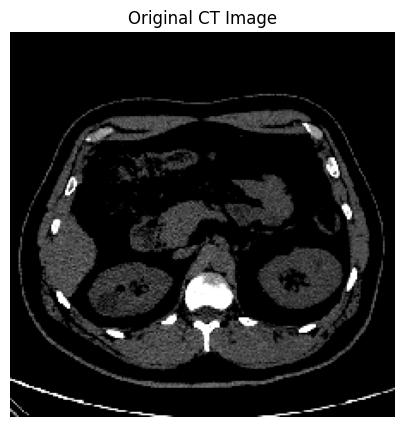

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_3']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


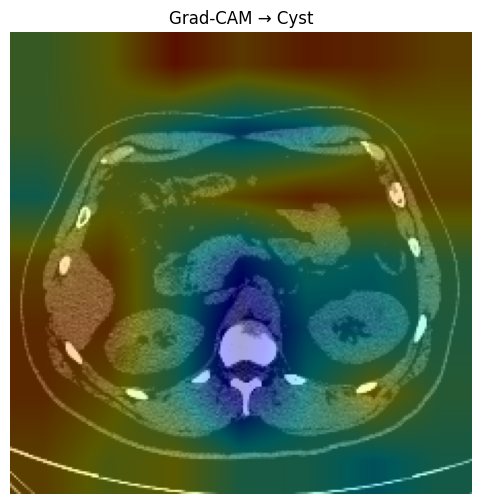

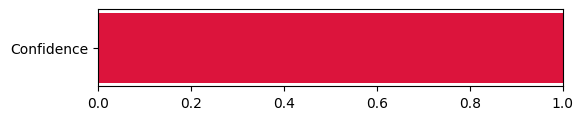


🧠 MINI DIAGNOSTIC REPORT
────────────────────────────
Prediction       : Cyst
Confidence       : 100.00%
Risk Level       : 🟡 MODERATE RISK
Clinical Insight : Benign cystic lesion detected. Follow-up imaging recommended.

📊 Class Probabilities:
Cyst: 100.00%
Normal: 0.00%
Stone: 0.00%
Tumor: 0.00%

📚 PATIENT EDUCATION & SUPPORT



In [ ]:
final_demo_dashboard(model)
